## heatmap

In [1]:
import seaborn as sns  # 导入seaborn库，用于高级数据可视化，提供美观的统计图形
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot模块，用于创建和定制图表
import pandas as pd  # 导入pandas库，用于数据处理和创建DataFrame
import numpy as np  # 导入numpy库，用于数值计算和生成随机数据

# 设置中文字体和样式
plt.rcParams['font.family'] = ['Times New Roman', 'STsong']  # 设置图表字体为Times New Roman和宋体，支持中英文显示
plt.rcParams['axes.unicode_minus'] = False  # 设置不显示负号为方块，确保负值符号正确显示

# 准备数据集
np.random.seed(42)  # 设置随机种子为42，确保生成的数据可重现

# 1. 相关系数矩阵
tips = sns.load_dataset('tips')  # 加载seaborn内置的tips数据集，包含餐厅消费数据
corr_matrix = tips[['total_bill', 'tip', 'size']].corr()  # 计算tips数据集中指定列的相关系数矩阵
# 用途：corr_matrix可用于热图展示变量间的相关性强度

# 2. 透视表数据
flights = sns.load_dataset('flights')  # 加载seaborn内置的flights数据集，包含航班乘客数据
flights_pivot = flights.pivot(index='month',  # 创建透视表，以'month'为行索引
                              columns='year',  # 以'year'为列索引
                              values='passengers')  # 以'passengers'为值，展示每月每年的乘客数
# 用途：flights_pivot可用于热图展示时间序列趋势

# 3. 随机数据矩阵
random_data = np.random.randn(10, 12)  # 生成10x12的随机正态分布数据矩阵
# 用途：random_data可用于热图展示随机数据的分布模式

# 4. 分类数据
category_data = pd.DataFrame(np.random.randint(0, 100, (8, 8)),  # 创建8x8随机整数矩阵，值范围0-99
                             columns=[f'特征{i+1}' for i in range(8)],  # 列名为特征1到特征8
                             index=[f'样本{i+1}' for i in range(8)])  # 行名为样本1到样本8
# 用途：category_data可用于热图展示分类或分组数据的模式

# 5. 不均匀数据（有极值）
uneven_data = np.random.randn(10, 10)  # 生成10x10的随机正态分布数据矩阵
uneven_data[0, 0] = 10  # 设置左上角值为10，模拟极大值
uneven_data[5, 5] = -10  # 设置中间值为-10，模拟极小值
# 用途：uneven_data可用于热图测试极值对可视化的影响

# 6. 混淆矩阵示例
confusion_matrix = np.array([[85, 10, 3, 2], [8, 92, 5, 3], [4, 6, 88, 7],  # 定义4x4混淆矩阵，表示分类结果
                             [3, 2, 4, 91]])
cm_df = pd.DataFrame(confusion_matrix,  # 将混淆矩阵转换为DataFrame
                     columns=['预测A', '预测B', '预测C', '预测D'],  # 列名为预测类别
                     index=['实际A', '实际B', '实际C', '实际D'])  # 行名为实际类别
# 用途：cm_df可用于热图展示分类模型的预测准确性

# 7. 时间序列热图数据
hours = [f'{i:02d}:00' for i in range(24)]  # 生成24小时时间点列表，格式如00:00到23:00
days = ['周一', '周二', '周三', '周四', '周五', '周六', '周日']  # 定义7天作为行索引
activity_data = pd.DataFrame(np.random.randint(10, 100, (7, 24)),  # 创建7x24随机整数矩阵，值范围10-99
                             columns=hours,  # 列名为24小时时间点
                             index=days)  # 行名为星期一到星期日
# 用途：activity_data可用于热图展示时间序列的活动强度

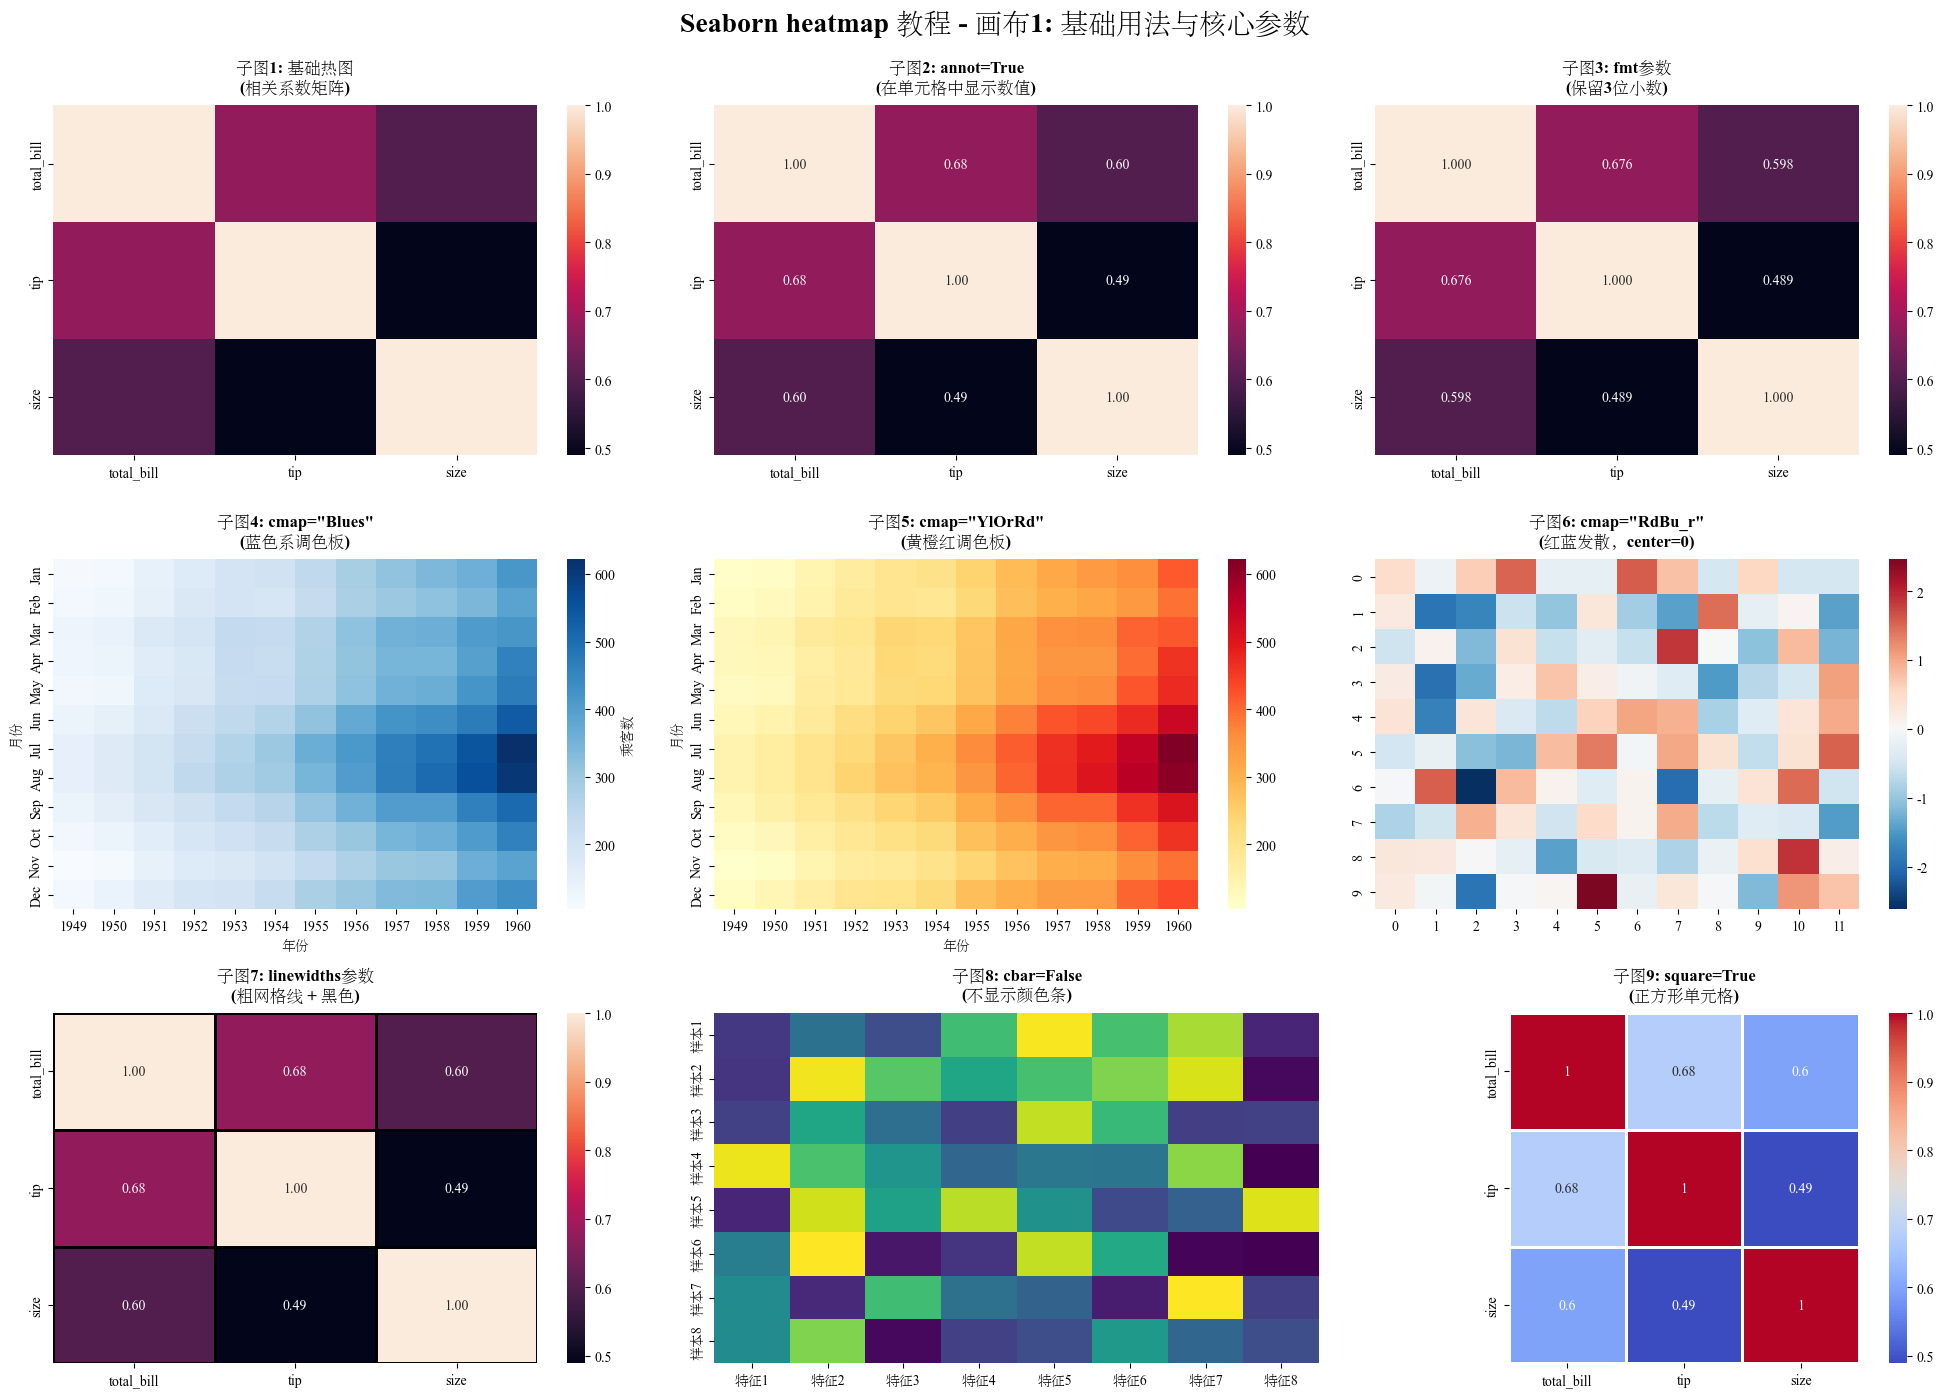

In [2]:
# ==================== 画布 1: 基础用法与核心参数 ====================
fig1 = plt.figure(figsize=(20, 14))  # 创建画布，尺寸20x14英寸，适合展示9个子图
fig1.suptitle(
    'Seaborn heatmap 教程 - 画布1: 基础用法与核心参数',  # 设置画布总标题，说明教程主题
    fontsize=20,  # 标题字体大小20，醒目显示
    fontweight='bold',  # 标题粗体，增强视觉效果
    y=0.995)  # 标题靠近画布顶部，避免遮挡子图

# ========== 子图 1：基础热图 - 最简单的用法 ==========
ax1 = plt.subplot(3, 3, 1)  # 创建3x3网格的第1个子图，展示基础热图
sns.heatmap(corr_matrix, ax=ax1)  # 绘制相关系数矩阵热图，corr_matrix为tips数据集的相关系数
# 参数说明：corr_matrix为输入数据，ax=ax1指定子图
ax1.set_title(
    '子图1: 基础热图\n(相关系数矩阵)',  # 设置标题，说明基础热图用途
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 2：annot参数 - 显示数值 ==========
ax2 = plt.subplot(3, 3, 2)  # 创建3x3网格的第2个子图，展示数值显示
sns.heatmap(corr_matrix, annot=True, ax=ax2, fmt='.2f')  # 绘制热图，显示单元格数值
# 参数说明：annot=True在单元格显示数值，fmt='.2f'保留2位小数，ax=ax2指定子图
ax2.set_title(
    '子图2: annot=True\n(在单元格中显示数值)',  # 设置标题，说明annot参数效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 3：fmt参数 - 数值格式 ==========
ax3 = plt.subplot(3, 3, 3)  # 创建3x3网格的第3个子图，展示数值格式控制
sns.heatmap(
    corr_matrix,  # 使用相关系数矩阵
    annot=True,  # 显示单元格数值
    fmt='.3f',  # 数值保留3位小数，增加精度
    ax=ax3,  # 指定子图对象为ax3
    annot_kws={'fontsize': 10})  # 设置数值字体大小为10，适配子图
ax3.set_title(
    '子图3: fmt参数\n(保留3位小数)',  # 设置标题，说明fmt参数效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 4：cmap参数 - 调色板(冷色系) ==========
ax4 = plt.subplot(3, 3, 4)  # 创建3x3网格的第4个子图，展示冷色系调色板
sns.heatmap(flights_pivot, cmap='Blues', ax=ax4,
            cbar_kws={'label': '乘客数'})  # 绘制flights_pivot热图，使用蓝色系调色板
# 参数说明：flights_pivot为透视表数据，cmap='Blues'设置冷色系调色板，cbar_kws设置颜色条标签
ax4.set_title(
    '子图4: cmap="Blues"\n(蓝色系调色板)',  # 设置标题，说明冷色系调色板效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax4.set_xlabel('年份')  # 设置x轴标签为“年份”
ax4.set_ylabel('月份')  # 设置y轴标签为“月份”

# ========== 子图 5：cmap参数 - 调色板(暖色系) ==========
ax5 = plt.subplot(3, 3, 5)  # 创建3x3网格的第5个子图，展示暖色系调色板
sns.heatmap(flights_pivot, cmap='YlOrRd', ax=ax5)  # 绘制flights_pivot热图，使用黄橙红调色板
# 参数说明：cmap='YlOrRd'设置暖色系调色板，ax=ax5指定子图
ax5.set_title(
    '子图5: cmap="YlOrRd"\n(黄橙红调色板)',  # 设置标题，说明暖色系调色板效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax5.set_xlabel('年份')  # 设置x轴标签为“年份”
ax5.set_ylabel('月份')  # 设置y轴标签为“月份”

# ========== 子图 6：cmap参数 - 发散调色板 ==========
ax6 = plt.subplot(3, 3, 6)  # 创建3x3网格的第6个子图，展示发散调色板
sns.heatmap(random_data, cmap='RdBu_r', center=0,
            ax=ax6)  # 绘制random_data热图，使用红蓝发散调色板
# 参数说明：random_data为随机数据，cmap='RdBu_r'设置发散调色板，center=0设置颜色中心点，ax=ax6指定子图
ax6.set_title(
    '子图6: cmap="RdBu_r"\n(红蓝发散，center=0)',  # 设置标题，说明发散调色板效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 7：linewidths参数 - 网格线 ==========
ax7 = plt.subplot(3, 3, 7)  # 创建3x3网格的第7个子图，展示网格线样式
sns.heatmap(
    corr_matrix,  # 使用相关系数矩阵
    annot=True,  # 显示单元格数值
    fmt='.2f',  # 数值保留2位小数
    linewidths=2,  # 设置网格线宽度为2，突出网格
    linecolor='black',  # 设置网格线颜色为黑色，增强对比
    ax=ax7)  # 指定子图对象为ax7
ax7.set_title(
    '子图7: linewidths参数\n(粗网格线 + 黑色)',  # 设置标题，说明网格线效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 8：cbar参数 - 隐藏颜色条 ==========
ax8 = plt.subplot(3, 3, 8)  # 创建3x3网格的第8个子图，展示隐藏颜色条
sns.heatmap(category_data, cmap='viridis', cbar=False,
            ax=ax8)  # 绘制category_data热图，隐藏颜色条
# 参数说明：category_data为分类数据，cmap='viridis'设置调色板，cbar=False禁用颜色条，ax=ax8指定子图
ax8.set_title(
    '子图8: cbar=False\n(不显示颜色条)',  # 设置标题，说明隐藏颜色条效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 9：square参数 - 正方形单元格 ==========
ax9 = plt.subplot(3, 3, 9)  # 创建3x3网格的第9个子图，展示正方形单元格
sns.heatmap(
    corr_matrix,  # 使用相关系数矩阵
    annot=True,  # 显示单元格数值
    square=True,  # 设置单元格为正方形，统一形状
    cmap='coolwarm',  # 使用coolwarm调色板，红蓝渐变
    ax=ax9,  # 指定子图对象为ax9
    linewidths=1,  # 设置网格线宽度为1，适中显示
    linecolor='white')  # 设置网格线颜色为白色，增强美观
ax9.set_title(
    '子图9: square=True\n(正方形单元格)',  # 设置标题，说明正方形单元格效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

plt.tight_layout()  # 自动调整子图间距，优化布局，避免重叠
plt.show()  # 显示整个画布，渲染所有子图

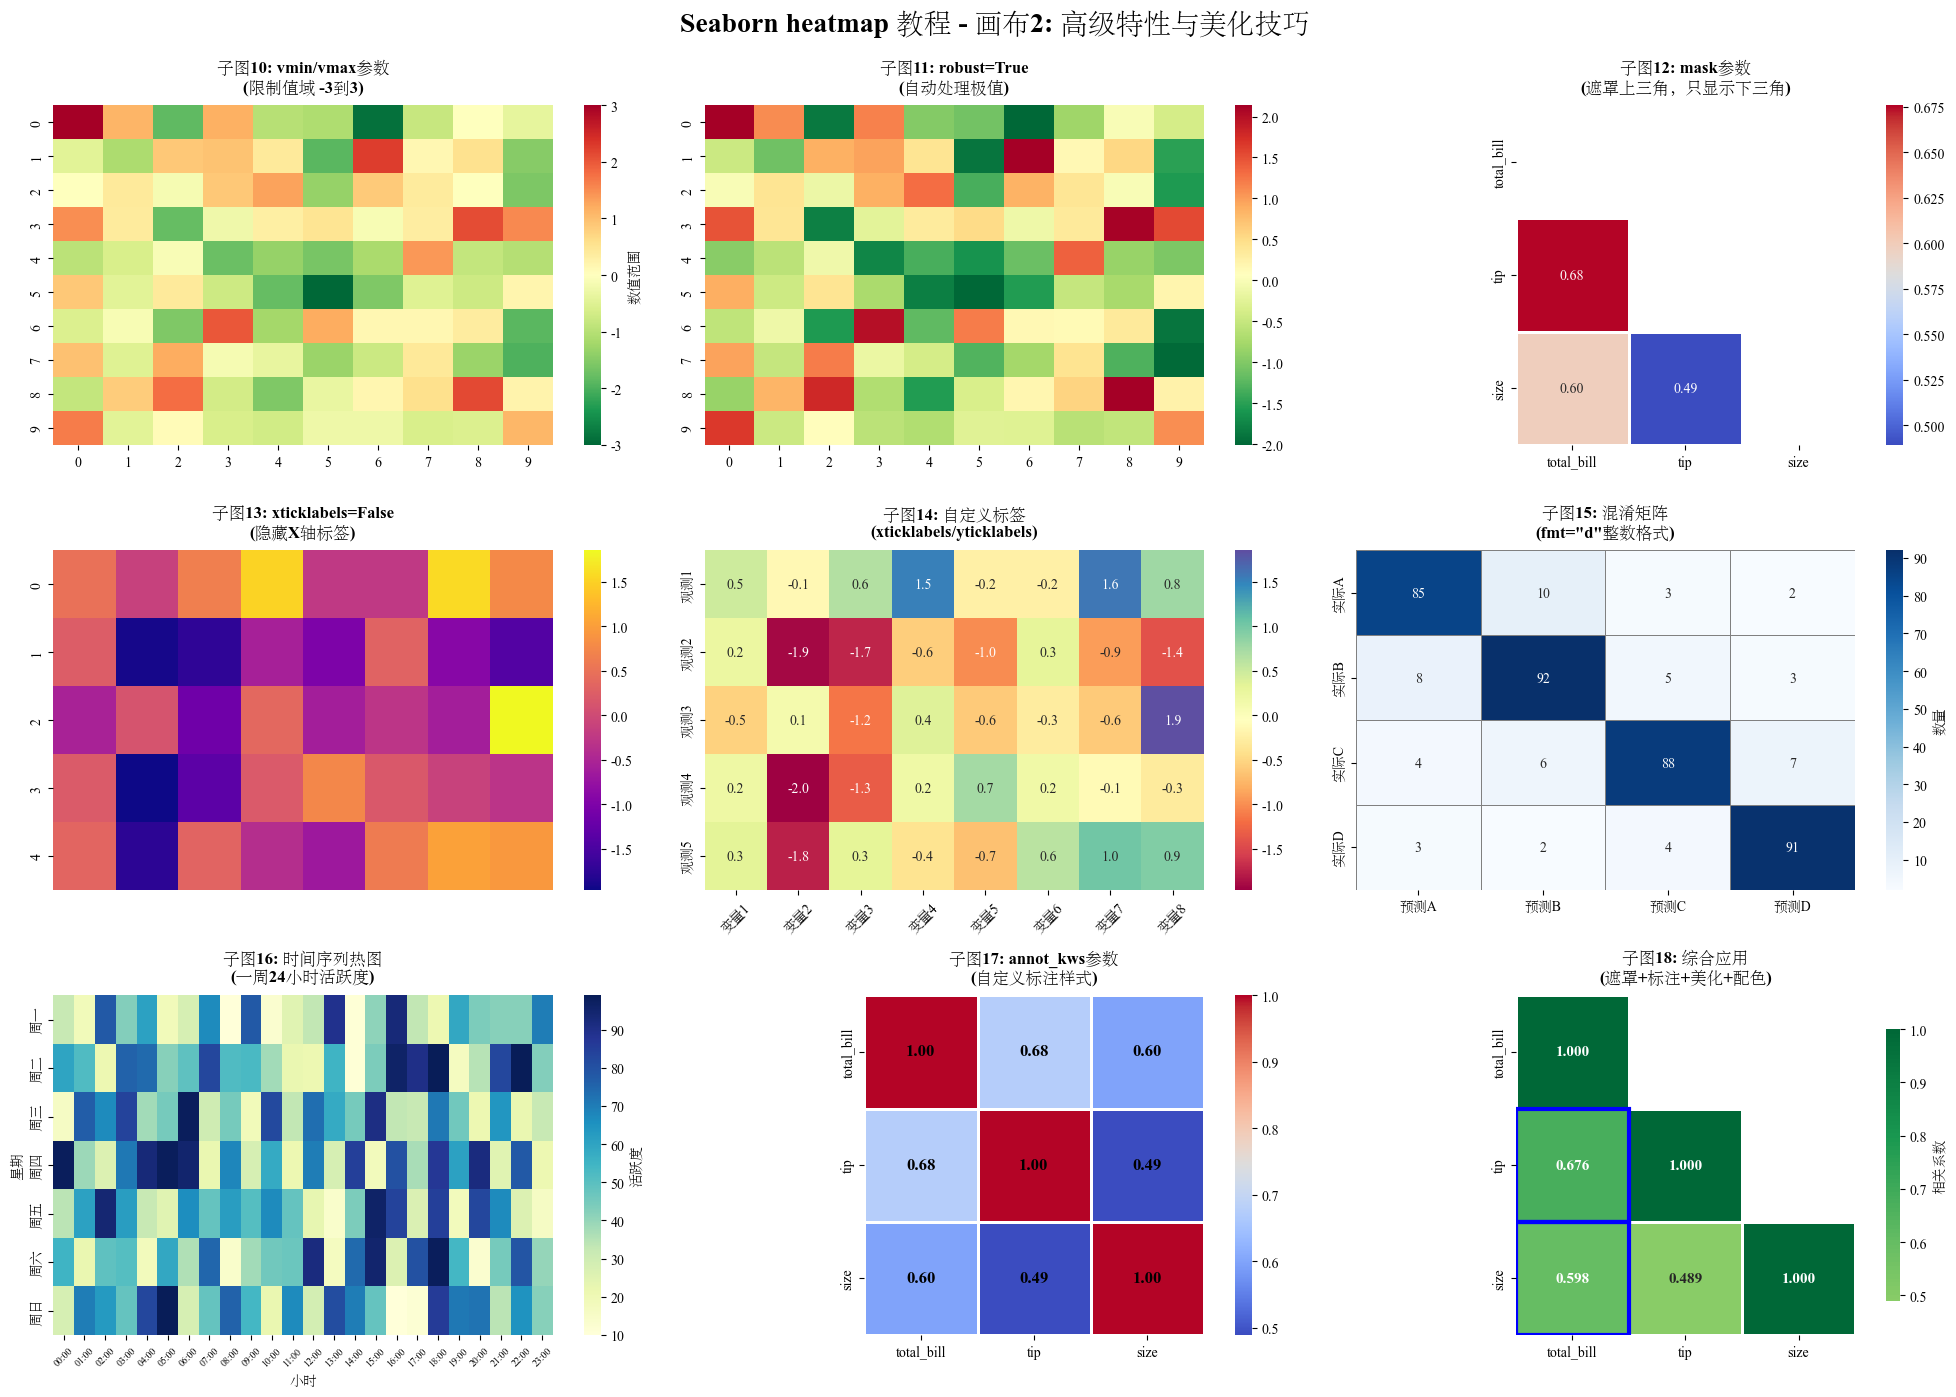

In [5]:
# ==================== 画布 2: 高级特性与美化技巧 ====================
fig2 = plt.figure(figsize=(20, 14))  # 创建画布，尺寸20x14英寸，适合展示9个子图
fig2.suptitle(
    'Seaborn heatmap 教程 - 画布2: 高级特性与美化技巧',  # 设置画布总标题，说明高级热图主题
    fontsize=20,  # 标题字体大小20，醒目显示
    fontweight='bold',  # 标题粗体，增强视觉效果
    y=0.995)  # 标题靠近画布顶部，避免遮挡子图

# ========== 子图 10：vmin/vmax参数 - 值域控制 ==========
ax10 = plt.subplot(3, 3, 1)  # 创建3x3网格的第1个子图，展示值域控制
sns.heatmap(
    uneven_data,  # 使用uneven_data数据集，包含极值
    vmin=-3,  # 设置颜色映射最小值为-3，限制下限
    vmax=3,  # 设置颜色映射最大值为3，限制上限
    cmap='RdYlGn_r',  # 使用红黄绿反转调色板，突出值域
    ax=ax10,  # 指定子图对象为ax10
    cbar_kws={'label': '数值范围'})  # 设置颜色条标签为“数值范围”
ax10.set_title(
    '子图10: vmin/vmax参数\n(限制值域 -3到3)',  # 设置标题，说明值域控制效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 11：robust参数 - 稳健显示 ==========
ax11 = plt.subplot(3, 3, 2)  # 创建3x3网格的第2个子图，展示稳健显示
sns.heatmap(uneven_data, robust=True, cmap='RdYlGn_r', ax=ax11)  # 绘制热图，启用稳健显示
# 参数说明：robust=True自动调整颜色映射，减少极值影响，cmap='RdYlGn_r'使用红黄绿反转调色板
ax11.set_title(
    '子图11: robust=True\n(自动处理极值)',  # 设置标题，说明robust参数效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 12：mask参数 - 遮罩上三角 ==========
ax12 = plt.subplot(3, 3, 3)  # 创建3x3网格的第3个子图，展示遮罩功能
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # 创建上三角遮罩，隐藏相关系数矩阵上三角
sns.heatmap(
    corr_matrix,  # 使用相关系数矩阵
    mask=mask,  # 应用上三角遮罩，仅显示下三角
    annot=True,  # 显示单元格数值
    fmt='.2f',  # 数值保留2位小数
    cmap='coolwarm',  # 使用红蓝渐变调色板
    ax=ax12,  # 指定子图对象为ax12
    square=True,  # 设置单元格为正方形，统一形状
    linewidths=1,  # 设置网格线宽度为1，适中显示
    linecolor='white')  # 设置网格线颜色为白色，增强美观
ax12.set_title(
    '子图12: mask参数\n(遮罩上三角，只显示下三角)',  # 设置标题，说明遮罩效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 13：xticklabels/yticklabels - 标签控制 ==========
ax13 = plt.subplot(3, 3, 4)  # 创建3x3网格的第4个子图，展示标签控制
sns.heatmap(
    random_data[:5, :8],  # 使用random_data的前5行8列子集
    xticklabels=False,  # 隐藏x轴标签，简化图形
    yticklabels=True,  # 显示y轴标签，保留默认索引
    cmap='plasma',  # 使用plasma调色板，渐变效果
    ax=ax13)  # 指定子图对象为ax13
ax13.set_title(
    '子图13: xticklabels=False\n(隐藏X轴标签)',  # 设置标题，说明标签控制效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 14：自定义标签 ==========
ax14 = plt.subplot(3, 3, 5)  # 创建3x3网格的第5个子图，展示自定义标签
custom_labels_x = [f'变量{i+1}' for i in range(8)]  # 创建x轴自定义标签：变量1到变量8
custom_labels_y = [f'观测{i+1}' for i in range(5)]  # 创建y轴自定义标签：观测1到观测5
sns.heatmap(
    random_data[:5, :8],  # 使用random_data的前5行8列子集
    xticklabels=custom_labels_x,  # 设置x轴自定义标签
    yticklabels=custom_labels_y,  # 设置y轴自定义标签
    cmap='Spectral',  # 使用Spectral调色板，多色渐变
    ax=ax14,  # 指定子图对象为ax14
    annot=True,  # 显示单元格数值
    fmt='.1f')  # 数值保留1位小数
ax14.set_title(
    '子图14: 自定义标签\n(xticklabels/yticklabels)',  # 设置标题，说明自定义标签效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax14.tick_params(axis='x', rotation=45)  # 旋转x轴标签45度，避免重叠

# ========== 子图 15：混淆矩阵可视化 ==========
ax15 = plt.subplot(3, 3, 6)  # 创建3x3网格的第6个子图，展示混淆矩阵
sns.heatmap(
    cm_df,  # 使用cm_df混淆矩阵数据
    annot=True,  # 显示单元格数值
    fmt='d',  # 数值格式为整数，适合计数数据
    cmap='Blues',  # 使用蓝色系调色板，突出计数大小
    ax=ax15,  # 指定子图对象为ax15
    linewidths=0.5,  # 设置网格线宽度为0.5，细腻显示
    linecolor='gray',  # 设置网格线颜色为灰色，适中对比
    cbar_kws={'label': '数量'})  # 设置颜色条标签为“数量”
ax15.set_title(
    '子图15: 混淆矩阵\n(fmt="d"整数格式)',  # 设置标题，说明混淆矩阵可视化
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 16：时间序列热图 ==========
ax16 = plt.subplot(3, 3, 7)  # 创建3x3网格的第7个子图，展示时间序列热图
sns.heatmap(activity_data, cmap='YlGnBu', ax=ax16,
            cbar_kws={'label': '活跃度'})  # 绘制activity_data热图，展示一周24小时活跃度
# 参数说明：cmap='YlGnBu'使用黄绿蓝调色板，cbar_kws设置颜色条标签为“活跃度”
ax16.set_title(
    '子图16: 时间序列热图\n(一周24小时活跃度)',  # 设置标题，说明时间序列可视化
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax16.set_xlabel('小时')  # 设置x轴标签为“小时”
ax16.set_ylabel('星期')  # 设置y轴标签为“星期”
ax16.tick_params(axis='x', rotation=45, labelsize=7)  # 旋转x轴标签45度，字体大小7，避免拥挤

# ========== 子图 17：annot_kws参数 - 标注样式 ==========
ax17 = plt.subplot(3, 3, 8)  # 创建3x3网格的第8个子图，展示标注样式控制
sns.heatmap(
    corr_matrix,  # 使用相关系数矩阵
    annot=True,  # 显示单元格数值
    fmt='.2f',  # 数值保留2位小数
    cmap='coolwarm',  # 使用红蓝渐变调色板
    ax=ax17,  # 指定子图对象为ax17
    annot_kws={  # 标注样式参数字典
        'fontsize': 12,  # 设置数值字体大小为12，突出显示
        'fontweight': 'bold',  # 设置数值字体为粗体
        'color': 'black'  # 设置数值颜色为黑色，增强对比
    },
    linewidths=2,  # 设置网格线宽度为2，突出网格
    linecolor='white',  # 设置网格线颜色为白色，增强美观
    square=True)  # 设置单元格为正方形，统一形状
ax17.set_title(
    '子图17: annot_kws参数\n(自定义标注样式)',  # 设置标题，说明标注样式效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 18：综合应用 - 专业级热图 ==========
ax18 = plt.subplot(3, 3, 9)  # 创建3x3网格的第9个子图，展示综合应用
# 计算相关系数矩阵
tips_corr = tips[['total_bill', 'tip',
                  'size']].corr()  # 重新计算tips数据集的相关系数矩阵，确保数据一致
# 创建遮罩（只显示下三角）
mask_tri = np.triu(np.ones_like(tips_corr, dtype=bool),
                   k=1)  # 创建上三角遮罩，k=1隐藏严格上三角
# 绘制热图
sns.heatmap(
    tips_corr,  # 使用相关系数矩阵
    mask=mask_tri,  # 应用上三角遮罩，仅显示下三角
    annot=True,  # 显示单元格数值
    fmt='.3f',  # 数值保留3位小数，增加精度
    cmap='RdYlGn',  # 使用红黄绿调色板，突出相关性
    center=0,  # 设置颜色中心点为0，适合相关系数
    square=True,  # 设置单元格为正方形，统一形状
    ax=ax18,  # 指定子图对象为ax18
    linewidths=2,  # 设置网格线宽度为2，突出网格
    linecolor='white',  # 设置网格线颜色为白色，增强美观
    cbar_kws={  # 颜色条参数字典
        'label': '相关系数',  # 设置颜色条标签为“相关系数”
        'shrink': 0.8  # 缩小颜色条至80%，优化布局
    },
    annot_kws={  # 标注样式参数字典
        'fontsize': 11,  # 设置数值字体大小为11
        'fontweight': 'bold'  # 设置数值字体为粗体
    })
ax18.set_title(
    '子图18: 综合应用\n(遮罩+标注+美化+配色)',  # 设置标题，说明综合应用效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
# 添加标注框
for i in range(len(tips_corr)):  # 遍历相关系数矩阵的行
    for j in range(i):  # 遍历下三角的列
        value = tips_corr.iloc[i, j]  # 获取单元格值
        if abs(value) > 0.5:  # 如果相关系数绝对值大于0.5
            ax18.add_patch(
                plt.Rectangle((j, i),
                              1,
                              1,
                              fill=False,
                              edgecolor='blue',
                              linewidth=3))  # 添加蓝色边框，突出强相关

plt.tight_layout()  # 自动调整子图间距，优化布局，避免重叠
plt.show()  # 显示整个画布，渲染所有子图

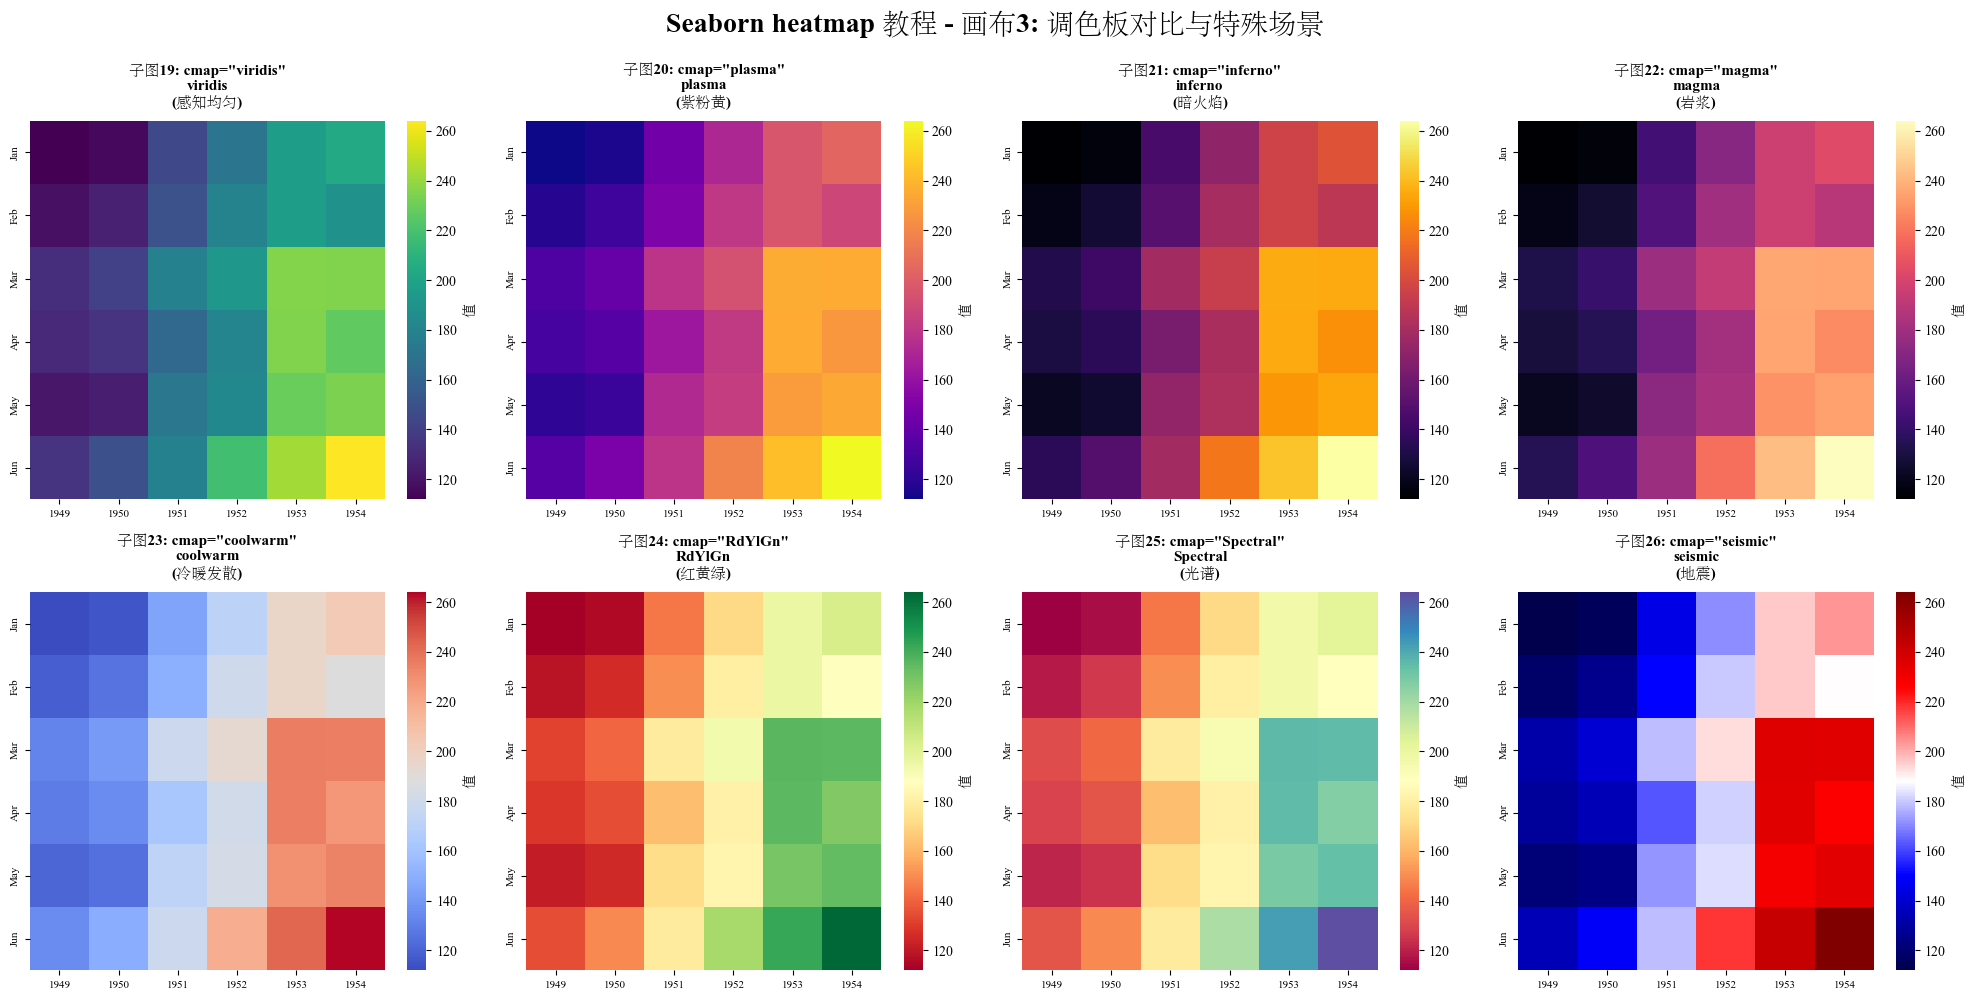

In [6]:
# ==================== 画布 3: 特殊场景与调色板对比 ====================
fig3 = plt.figure(figsize=(20, 10))  # 创建画布，尺寸20x10英寸，适合展示8个子图
fig3.suptitle(
    'Seaborn heatmap 教程 - 画布3: 调色板对比与特殊场景',  # 设置画布总标题，说明调色板对比主题
    fontsize=20,  # 标题字体大小20，醒目显示
    fontweight='bold',  # 标题粗体，增强视觉效果
    y=0.995)  # 标题靠近画布顶部，避免遮挡子图

# 准备相同数据用于对比
demo_data = flights_pivot.iloc[:6, :6]  # 从flights_pivot选取前6行6列子集，确保调色板对比使用相同数据
# 用途：demo_data为航班乘客数据的子集，适合展示不同调色板效果

# ========== 子图 19-26：不同调色板对比 ==========
cmaps = [  # 定义8种调色板，用于对比不同颜色映射效果
    'viridis', 'plasma', 'inferno', 'magma', 'coolwarm', 'RdYlGn', 'Spectral',
    'seismic'
]
titles = [  # 定义子图标题，描述每种调色板的特性
    'viridis\n(感知均匀)', 'plasma\n(紫粉黄)', 'inferno\n(暗火焰)', 'magma\n(岩浆)',
    'coolwarm\n(冷暖发散)', 'RdYlGn\n(红黄绿)', 'Spectral\n(光谱)', 'seismic\n(地震)'
]

for idx, (cmap, title) in enumerate(zip(cmaps, titles)):  # 遍历调色板和标题的配对
    ax = plt.subplot(2, 4, idx + 1)  # 创建2x4网格的子图，索引从1开始
    sns.heatmap(demo_data, cmap=cmap, ax=ax, cbar_kws={'label':
                                                       '值'})  # 绘制热图，使用指定调色板
    # 参数说明：demo_data为输入数据，cmap指定调色板，ax指定子图，cbar_kws设置颜色条标签为“值”
    ax.set_title(
        f'子图{19+idx}: cmap="{cmap}"\n{title}',  # 设置标题，说明调色板名称和特性
        fontsize=11,
        fontweight='bold',
        pad=10)  # 标题字体11，粗体，间距10
    ax.set_xlabel('')  # 清空x轴标签，简化图形
    ax.set_ylabel('')  # 清空y轴标签，专注于调色板对比
    ax.tick_params(labelsize=8)  # 设置刻度标签字体大小为8，适合子图比例

plt.tight_layout()  # 自动调整子图间距，优化布局，避免重叠
plt.show()  # 显示整个画布，渲染所有子图

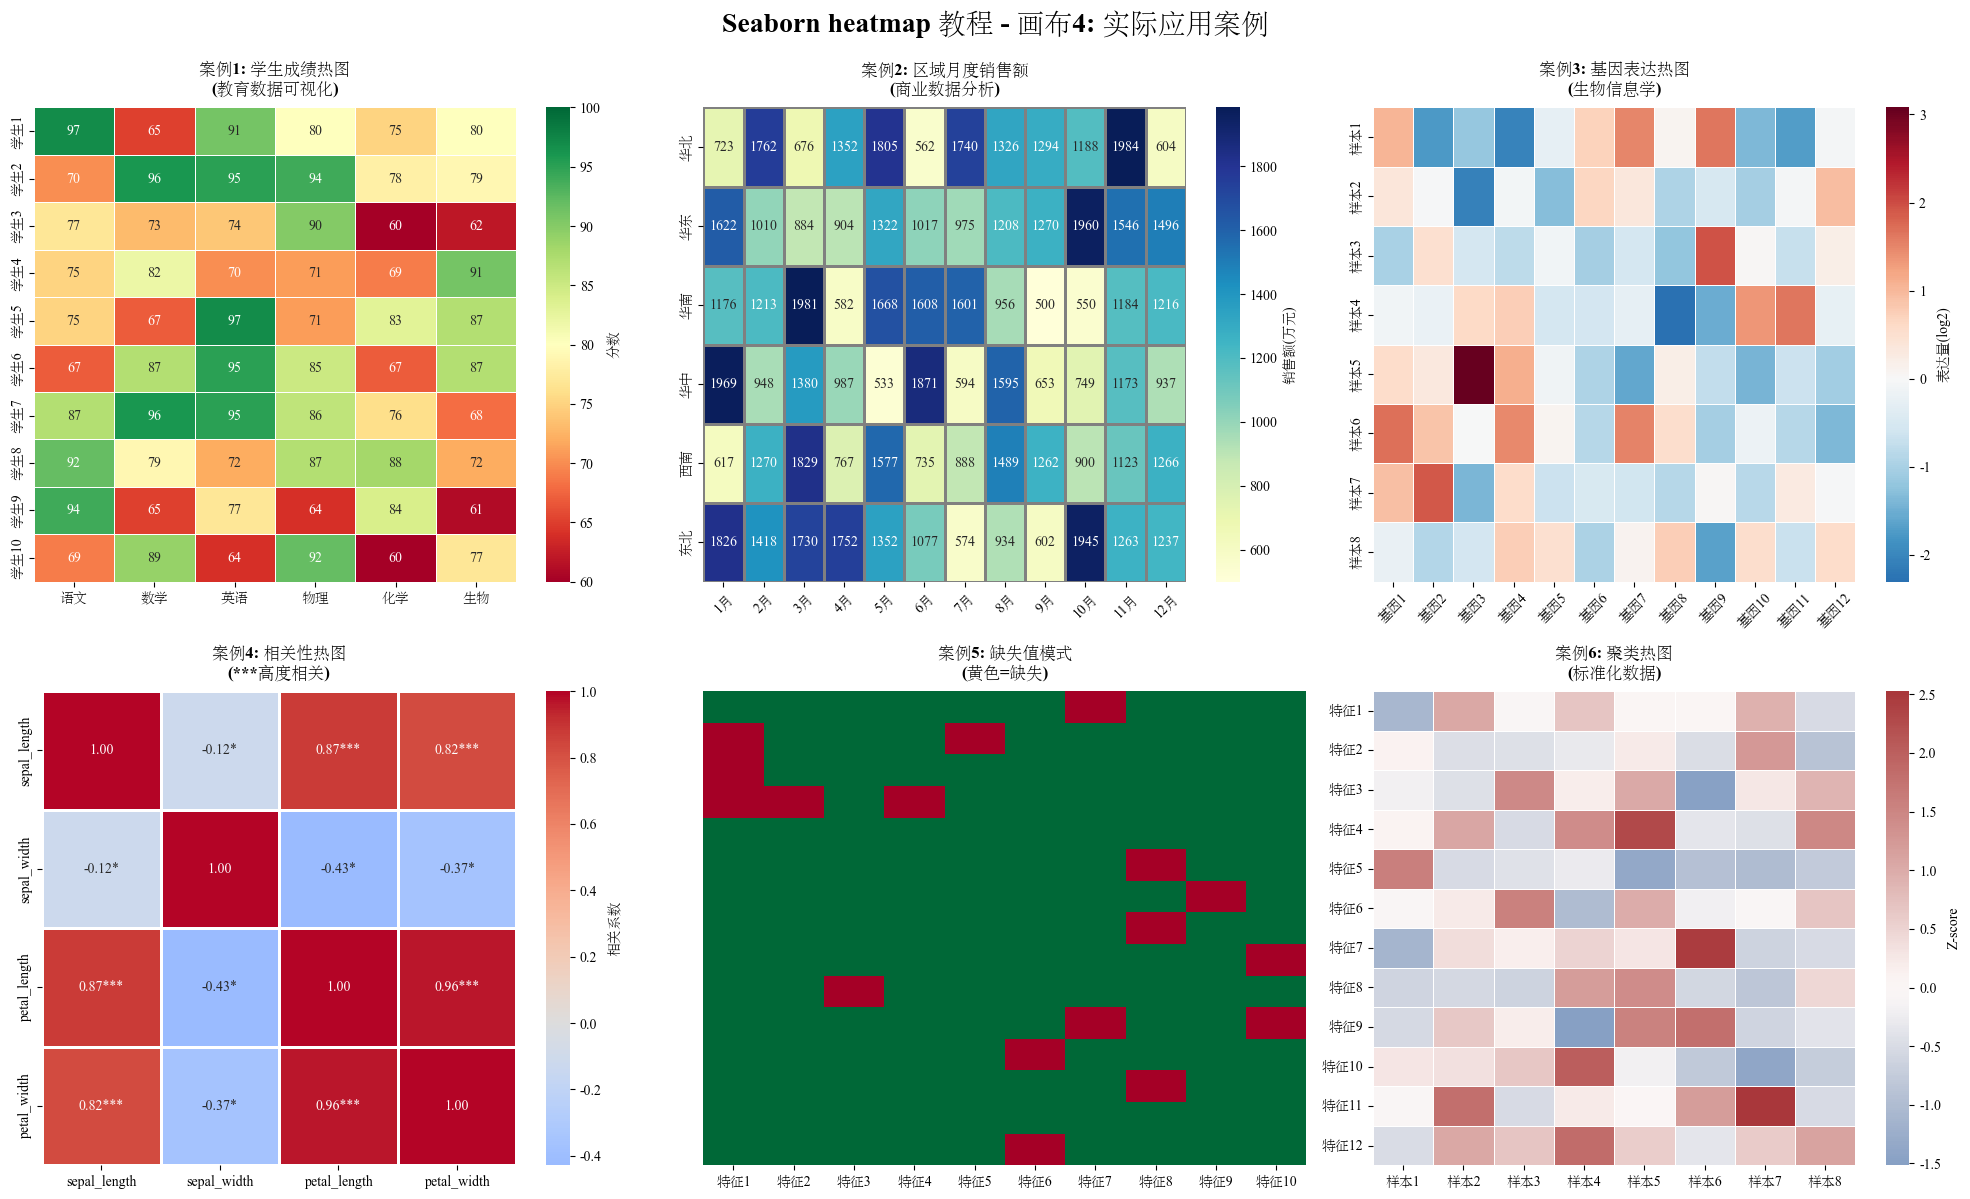

In [7]:
# ==================== 画布 4: 实际应用案例 ====================
fig4 = plt.figure(figsize=(20, 12))  # 创建画布，尺寸20x12英寸，适合展示6个子图
fig4.suptitle(
    'Seaborn heatmap 教程 - 画布4: 实际应用案例',  # 设置画布总标题，说明实际应用案例
    fontsize=20,  # 标题字体大小20，醒目显示
    fontweight='bold',  # 标题粗体，增强视觉效果
    y=0.995)  # 标题靠近画布顶部，避免遮挡子图

# ========== 子图 27：学生成绩热图 ==========
ax27 = plt.subplot(2, 3, 1)  # 创建2x3网格的第1个子图，展示学生成绩热图
subjects = ['语文', '数学', '英语', '物理', '化学', '生物']  # 定义6门学科作为列名
students = [f'学生{i+1}' for i in range(10)]  # 定义10名学生作为行名
scores = pd.DataFrame(
    np.random.randint(60, 100, (10, 6)),  # 创建10x6随机整数矩阵，分数范围60-100
    columns=subjects,  # 设置列名为学科
    index=students)  # 设置行名为学生
sns.heatmap(
    scores,  # 绘制学生成绩热图
    annot=True,  # 显示单元格数值
    fmt='d',  # 数值格式为整数，适合分数
    cmap='RdYlGn',  # 使用红黄绿调色板，突出分数高低
    ax=ax27,  # 指定子图对象为ax27
    linewidths=0.5,  # 设置网格线宽度为0.5，细腻显示
    linecolor='white',  # 设置网格线颜色为白色，增强美观
    vmin=60,  # 设置颜色映射最小值为60，与分数范围一致
    vmax=100,  # 设置颜色映射最大值为100，与分数范围一致
    cbar_kws={'label': '分数'})  # 设置颜色条标签为“分数”
ax27.set_title(
    '案例1: 学生成绩热图\n(教育数据可视化)',  # 设置标题，说明教育数据应用
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 28：销售数据热图 ==========
ax28 = plt.subplot(2, 3, 2)  # 创建2x3网格的第2个子图，展示销售数据热图
months_cn = [
    '1月', '2月', '3月', '4月', '5月', '6月', '7月', '8月', '9月', '10月', '11月', '12月'
]  # 定义12个月作为列名
regions = ['华北', '华东', '华南', '华中', '西南', '东北']  # 定义6个区域作为行名
sales = pd.DataFrame(
    np.random.randint(500, 2000, (6, 12)),  # 创建6x12随机整数矩阵，销售额范围500-2000
    columns=months_cn,  # 设置列名为月份
    index=regions)  # 设置行名为区域
sns.heatmap(
    sales,  # 绘制销售数据热图
    annot=True,  # 显示单元格数值
    fmt='d',  # 数值格式为整数，适合销售额
    cmap='YlGnBu',  # 使用黄绿蓝调色板，突出销售额大小
    ax=ax28,  # 指定子图对象为ax28
    linewidths=1,  # 设置网格线宽度为1，适中显示
    linecolor='gray',  # 设置网格线颜色为灰色，适中对比
    cbar_kws={'label': '销售额(万元)'})  # 设置颜色条标签为“销售额(万元)”
ax28.set_title(
    '案例2: 区域月度销售额\n(商业数据分析)',  # 设置标题，说明商业数据应用
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax28.tick_params(axis='x', rotation=45)  # 旋转x轴标签45度，避免重叠

# ========== 子图 29：基因表达热图 ==========
ax29 = plt.subplot(2, 3, 3)  # 创建2x3网格的第3个子图，展示基因表达热图
genes = [f'基因{i+1}' for i in range(12)]  # 定义12个基因作为列名
samples = [f'样本{i+1}' for i in range(8)]  # 定义8个样本作为行名
expression = pd.DataFrame(np.random.randn(8, 12), columns=genes,
                          index=samples)  # 创建8x12随机正态分布矩阵，模拟基因表达量
sns.heatmap(
    expression,  # 绘制基因表达热图
    cmap='RdBu_r',  # 使用红蓝反转调色板，适合表达量正负值
    center=0,  # 设置颜色中心点为0，突出正负表达
    ax=ax29,  # 指定子图对象为ax29
    linewidths=0.5,  # 设置网格线宽度为0.5，细腻显示
    linecolor='white',  # 设置网格线颜色为白色，增强美观
    cbar_kws={'label': '表达量(log2)'})  # 设置颜色条标签为“表达量(log2)”
ax29.set_title(
    '案例3: 基因表达热图\n(生物信息学)',  # 设置标题，说明生物信息学应用
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10
ax29.tick_params(axis='x', rotation=45)  # 旋转x轴标签45度，避免重叠

# ========== 子图 30：相关性热图(带显著性) ==========
ax30 = plt.subplot(2, 3, 4)  # 创建2x3网格的第4个子图，展示相关性热图
# 创建相关系数矩阵
iris_data = sns.load_dataset('iris')  # 加载seaborn内置的iris数据集
iris_corr = iris_data.drop('species', axis=1).corr()  # 计算数值列的相关系数矩阵，排除物种列
# 创建标注（添加星号表示显著性）
annot_array = iris_corr.values.copy()  # 复制相关系数矩阵数值
annot_labels = np.empty_like(annot_array, dtype=object)  # 创建空对象数组，用于存储带星号的标注
for i in range(annot_array.shape[0]):  # 遍历矩阵行
    for j in range(annot_array.shape[1]):  # 遍历矩阵列
        val = annot_array[i, j]  # 获取当前单元格值
        if i != j:  # 非对角线元素
            if abs(val) > 0.8:  # 相关系数绝对值>0.8，标注3星
                annot_labels[i, j] = f'{val:.2f}***'
            elif abs(val) > 0.6:  # 相关系数绝对值>0.6，标注2星
                annot_labels[i, j] = f'{val:.2f}**'
            else:  # 其他情况标注1星
                annot_labels[i, j] = f'{val:.2f}*'
        else:  # 对角线元素（自相关=1）
            annot_labels[i, j] = f'{val:.2f}'
sns.heatmap(
    iris_corr,  # 绘制相关性热图
    annot=annot_labels,  # 使用带星号的自定义标注
    fmt='',  # 禁用默认格式，使用自定义字符串
    cmap='coolwarm',  # 使用红蓝渐变调色板，突出相关性
    center=0,  # 设置颜色中心点为0，适合相关系数
    ax=ax30,  # 指定子图对象为ax30
    square=True,  # 设置单元格为正方形，统一形状
    linewidths=1,  # 设置网格线宽度为1，适中显示
    linecolor='white',  # 设置网格线颜色为白色，增强美观
    cbar_kws={'label': '相关系数'})  # 设置颜色条标签为“相关系数”
ax30.set_title(
    '案例4: 相关性热图\n(***高度相关)',  # 设置标题，说明显著性标注效果
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 31：缺失值热图 ==========
ax31 = plt.subplot(2, 3, 5)  # 创建2x3网格的第5个子图，展示缺失值模式
# 创建带缺失值的数据
data_with_nan = pd.DataFrame(
    np.random.randn(15, 10),  # 创建15x10随机正态分布矩阵
    columns=[f'特征{i+1}' for i in range(10)])  # 设置列名为特征1到特征10
# 随机设置一些缺失值
mask_nan = np.random.rand(15, 10) < 0.1  # 创建10%概率的随机掩码，用于设置缺失值
data_with_nan[mask_nan] = np.nan  # 将掩码对应位置设为NaN
# 可视化缺失值模式
sns.heatmap(
    data_with_nan.isnull(),  # 绘制缺失值热图，True表示缺失，False表示非缺失
    cmap='RdYlGn_r',  # 使用红黄绿反转调色板，黄色表示缺失
    cbar=False,  # 禁用颜色条，简化图形
    ax=ax31,  # 指定子图对象为ax31
    yticklabels=False)  # 隐藏y轴标签，专注于缺失模式
ax31.set_title(
    '案例5: 缺失值模式\n(黄色=缺失)',  # 设置标题，说明缺失值可视化
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

# ========== 子图 32：分层聚类热图(简化版) ==========
ax32 = plt.subplot(2, 3, 6)  # 创建2x3网格的第6个子图，展示聚类热图
# 创建聚类数据
cluster_data = pd.DataFrame(
    np.random.randn(12, 8),  # 创建12x8随机正态分布矩阵，模拟标准化数据
    columns=[f'样本{i+1}' for i in range(8)],  # 设置列名为样本1到样本8
    index=[f'特征{i+1}' for i in range(12)])  # 设置行名为特征1到特征12
sns.heatmap(
    cluster_data,  # 绘制聚类热图
    cmap='vlag',  # 使用vlag调色板，适合标准化数据
    center=0,  # 设置颜色中心点为0，突出正负值
    ax=ax32,  # 指定子图对象为ax32
    linewidths=0.5,  # 设置网格线宽度为0.5，细腻显示
    linecolor='white',  # 设置网格线颜色为白色，增强美观
    cbar_kws={'label': 'Z-score'})  # 设置颜色条标签为“Z-score”
ax32.set_title(
    '案例6: 聚类热图\n(标准化数据)',  # 设置标题，说明聚类数据可视化
    fontsize=12,
    fontweight='bold',
    pad=10)  # 标题字体12，粗体，间距10

plt.tight_layout()  # 自动调整子图间距，优化布局，避免重叠
plt.show()  # 显示整个画布，渲染所有子图

In [8]:
print("=" * 80)
print("📊 Seaborn heatmap 教程完成!")
print("=" * 80)
print("\n✅ 画布1覆盖内容:")
print("  • 基础热图: 相关系数矩阵")
print("  • annot参数: 显示数值")
print("  • fmt参数: 数值格式(.2f/.3f/d)")
print("  • cmap参数: 调色板(Blues/YlOrRd/RdBu_r等)")
print("  • linewidths/linecolor: 网格线样式")
print("  • cbar参数: 颜色条控制")
print("  • square参数: 正方形单元格")
print("\n✅ 画布2覆盖内容:")
print("  • vmin/vmax: 值域范围控制")
print("  • robust参数: 稳健处理极值")
print("  • mask参数: 遮罩特定区域")
print("  • xticklabels/yticklabels: 标签控制")
print("  • 自定义标签: 完全自定义")
print("  • 混淆矩阵: 分类结果可视化")
print("  • 时间序列: 周期性模式展示")
print("  • annot_kws: 标注样式定制")
print("  • 综合应用: 多参数组合")
print("\n✅ 画布3覆盖内容:")
print("  • 8种常用调色板对比:")
print("    - viridis, plasma, inferno, magma (感知均匀)")
print("    - coolwarm, RdYlGn, Spectral, seismic (发散型)")
print("\n✅ 画布4覆盖内容:")
print("  • 6个实际应用案例:")
print("    1. 学生成绩热图 (教育)")
print("    2. 区域销售热图 (商业)")
print("    3. 基因表达热图 (生物)")
print("    4. 相关性热图 (统计)")
print("    5. 缺失值模式 (数据质量)")
print("    6. 聚类热图 (机器学习)")
print("\n" + "=" * 80)
print("💡 调色板选择建议:")
print("  • 连续数据(单调):")
print("    - Blues, Greens, Reds (单色系)")
print("    - YlOrRd, YlGnBu (多色渐变)")
print("    - viridis, plasma (感知均匀)")
print("\n  • 发散数据(有中心点):")
print("    - RdBu_r, RdYlGn (红蓝/红绿)")
print("    - coolwarm, seismic (冷暖)")
print("    - 设置 center=0")
print("\n  • 分类数据:")
print("    - Set1, Set2, Set3")
print("    - Paired, Accent")
print("=" * 80)
print("\n🎯 使用技巧:")
print("  1. annot=True 显示具体数值")
print("  2. square=True 让单元格更规整")
print("  3. mask 遮罩对角线或上三角")
print("  4. robust=True 处理异常值")
print("  5. linewidths 增加网格线提高可读性")
print("  6. cbar_kws 自定义颜色条标签")
print("  7. 根据数据类型选择合适调色板")
print("=" * 80)

📊 Seaborn heatmap 教程完成!

✅ 画布1覆盖内容:
  • 基础热图: 相关系数矩阵
  • annot参数: 显示数值
  • fmt参数: 数值格式(.2f/.3f/d)
  • cmap参数: 调色板(Blues/YlOrRd/RdBu_r等)
  • linewidths/linecolor: 网格线样式
  • cbar参数: 颜色条控制
  • square参数: 正方形单元格

✅ 画布2覆盖内容:
  • vmin/vmax: 值域范围控制
  • robust参数: 稳健处理极值
  • mask参数: 遮罩特定区域
  • xticklabels/yticklabels: 标签控制
  • 自定义标签: 完全自定义
  • 混淆矩阵: 分类结果可视化
  • 时间序列: 周期性模式展示
  • annot_kws: 标注样式定制
  • 综合应用: 多参数组合

✅ 画布3覆盖内容:
  • 8种常用调色板对比:
    - viridis, plasma, inferno, magma (感知均匀)
    - coolwarm, RdYlGn, Spectral, seismic (发散型)

✅ 画布4覆盖内容:
  • 6个实际应用案例:
    1. 学生成绩热图 (教育)
    2. 区域销售热图 (商业)
    3. 基因表达热图 (生物)
    4. 相关性热图 (统计)
    5. 缺失值模式 (数据质量)
    6. 聚类热图 (机器学习)

💡 调色板选择建议:
  • 连续数据(单调):
    - Blues, Greens, Reds (单色系)
    - YlOrRd, YlGnBu (多色渐变)
    - viridis, plasma (感知均匀)

  • 发散数据(有中心点):
    - RdBu_r, RdYlGn (红蓝/红绿)
    - coolwarm, seismic (冷暖)
    - 设置 center=0

  • 分类数据:
    - Set1, Set2, Set3
    - Paired, Accent

🎯 使用技巧:
  1. annot=True 显示具体数值
  2. square=True 让单元格更规整
  3. mask 遮罩对角

## clustermap

In [9]:
import seaborn as sns  # 导入seaborn库，用于高级数据可视化，包括clustermap
import matplotlib.pyplot as plt  # 导入matplotlib.pyplot模块，用于创建和定制图表
import pandas as pd  # 导入pandas库，用于数据处理和创建DataFrame
import numpy as np  # 导入numpy库，用于数值计算和生成随机数据
from scipy.cluster.hierarchy import dendrogram, linkage  # 导入scipy层次聚类工具，用于生成树状图
from scipy.spatial.distance import pdist  # 导入pdist计算距离矩阵，用于聚类

# 准备数据集
np.random.seed(42)  # 设置随机种子为42，确保生成的数据可重现

# 1. 基础数据矩阵
basic_data = pd.DataFrame(
    np.random.randn(10, 8),  # 创建10x8随机正态分布矩阵
    columns=[f'特征{i+1}' for i in range(8)],  # 列名为特征1到特征8
    index=[f'样本{i+1}' for i in range(10)])  # 行名为样本1到样本10
# 用途：basic_data可用于展示clustermap的基础聚类效果

# 2. 基因表达数据
genes = [f'基因{i+1}' for i in range(20)]  # 定义20个基因作为行名
samples = [f'样本{i+1}' for i in range(12)]  # 定义12个样本作为列名
gene_expression = pd.DataFrame(
    np.random.randn(20, 12),  # 创建20x12随机正态分布矩阵，模拟基因表达量
    columns=samples,  # 设置列名为样本
    index=genes)  # 设置行名为基因
# 用途：gene_expression适合展示生物信息学中的聚类热图

# 3. 学生成绩数据
subjects = ['语文', '数学', '英语', '物理', '化学', '生物', '历史', '地理']  # 定义8门学科作为列名
students = [f'学生{chr(65+i)}' for i in range(15)]  # 定义15名学生（A-O）作为行名
scores = pd.DataFrame(
    np.random.randint(60, 100, (15, 8)),  # 创建15x8随机整数矩阵，分数范围60-100
    columns=subjects,  # 设置列名为学科
    index=students)  # 设置行名为学生
# 用途：scores可用于展示教育场景中的学生成绩聚类

# 4. 时间序列数据（不同模式）
time_points = [f'T{i}' for i in range(24)]  # 定义24个时间点作为列名
features = [f'指标{i+1}' for i in range(10)]  # 定义10个指标作为行名
time_series = pd.DataFrame(
    np.random.randn(10, 24),  # 创建10x24随机正态分布矩阵，模拟时间序列
    columns=time_points,  # 设置列名为时间点
    index=features)  # 设置行名为指标
# 用途：time_series适合展示时间序列数据的聚类模式

# 5. 鸢尾花数据集
iris = sns.load_dataset('iris')  # 加载seaborn内置的iris数据集
iris_data = iris.drop('species', axis=1)  # 移除物种列，仅保留数值特征
# 用途：iris_data可用于展示经典数据集的聚类热图

# 6. 创建有明显分组的数据
group_data = pd.DataFrame()  # 创建空DataFrame，用于存储分组数据
# 第一组
group_data = pd.concat([  # 合并三组数据
    pd.DataFrame(
        np.random.randn(5, 6) + 2,  # 创建5x6随机正态分布矩阵，偏移+2，模拟A组高值
        columns=[f'特征{i+1}' for i in range(6)],  # 列名为特征1到特征6
        index=[f'A组{i+1}' for i in range(5)]),  # 行名为A组1到A组5
    # 第二组
    pd.DataFrame(
        np.random.randn(5, 6) - 2,  # 创建5x6随机正态分布矩阵，偏移-2，模拟B组低值
        columns=[f'特征{i+1}' for i in range(6)],  # 列名为特征1到特征6
        index=[f'B组{i+1}' for i in range(5)]),  # 行名为B组1到B组5
    # 第三组
    pd.DataFrame(
        np.random.randn(5, 6) + 0,  # 创建5x6随机正态分布矩阵，无偏移，模拟C组中值
        columns=[f'特征{i+1}' for i in range(6)],  # 列名为特征1到特征6
        index=[f'C组{i+1}' for i in range(5)])  # 行名为C组1到C组5
])
# 用途：group_data具有明显分组特征，适合展示clustermap的聚类效果

print("=" * 80)  # 打印80个等号，创建分隔线，提升输出可读性
print("📊 Seaborn clustermap 教程")  # 打印教程标题，表明主题为clustermap教学
print("=" * 80)  # 再次打印分隔线，保持格式一致
print("\n⚠️  重要提示:")  # 打印提示标题，突出clustermap特性说明
print("  clustermap 是【图级函数】(Figure-level)，不同于 heatmap【轴级函数】"
      )  # 说明clustermap为图级函数，自动管理画布
print("  • clustermap 自动创建 Figure，包含热图和树状图")  # 说明clustermap自动生成热图和聚类树
print("  • clustermap 会自动进行层次聚类")  # 说明clustermap默认执行行和列的层次聚类
print(
    "  • clustermap 返回 ClusterGrid 对象")  # 说明clustermap返回ClusterGrid对象，便于进一步定制
print("  • clustermap 默认同时对行和列进行聚类")  # 说明默认对行和列进行聚类分析
print("=" * 80)  # 打印分隔线，结束提示部分

📊 Seaborn clustermap 教程

⚠️  重要提示:
  clustermap 是【图级函数】(Figure-level)，不同于 heatmap【轴级函数】
  • clustermap 自动创建 Figure，包含热图和树状图
  • clustermap 会自动进行层次聚类
  • clustermap 返回 ClusterGrid 对象
  • clustermap 默认同时对行和列进行聚类



【第一部分】基础用法

# ========== 示例 1：基础 clustermap ==========


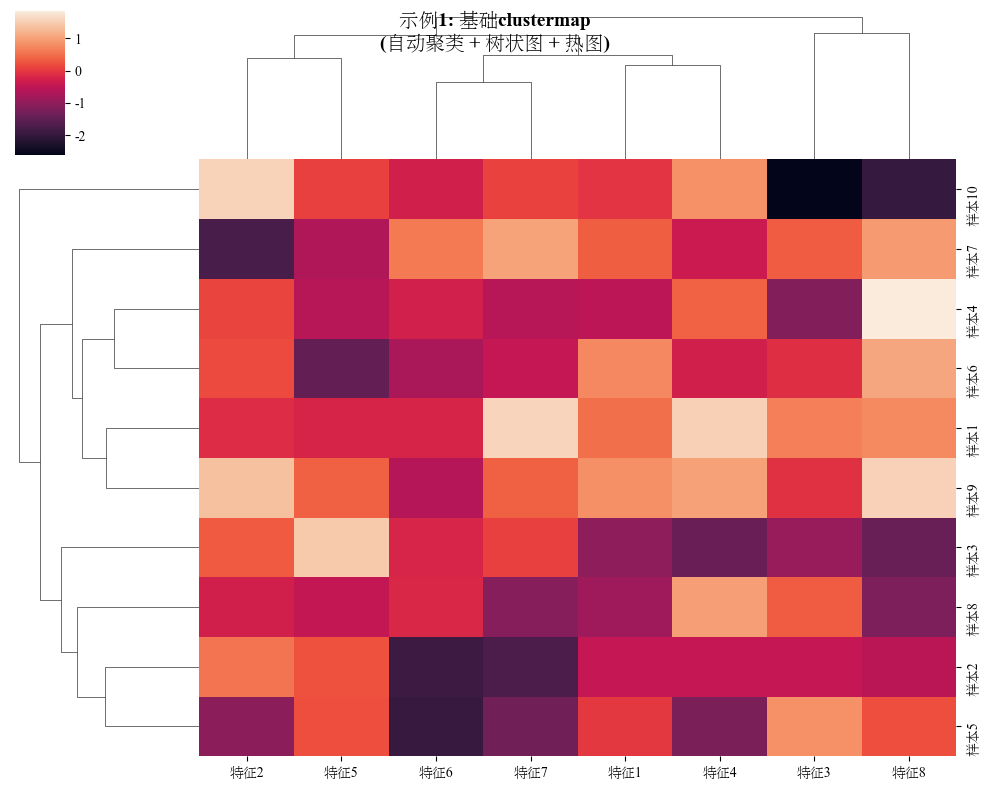


# ========== 示例 2：annot参数 - 显示数值 ==========


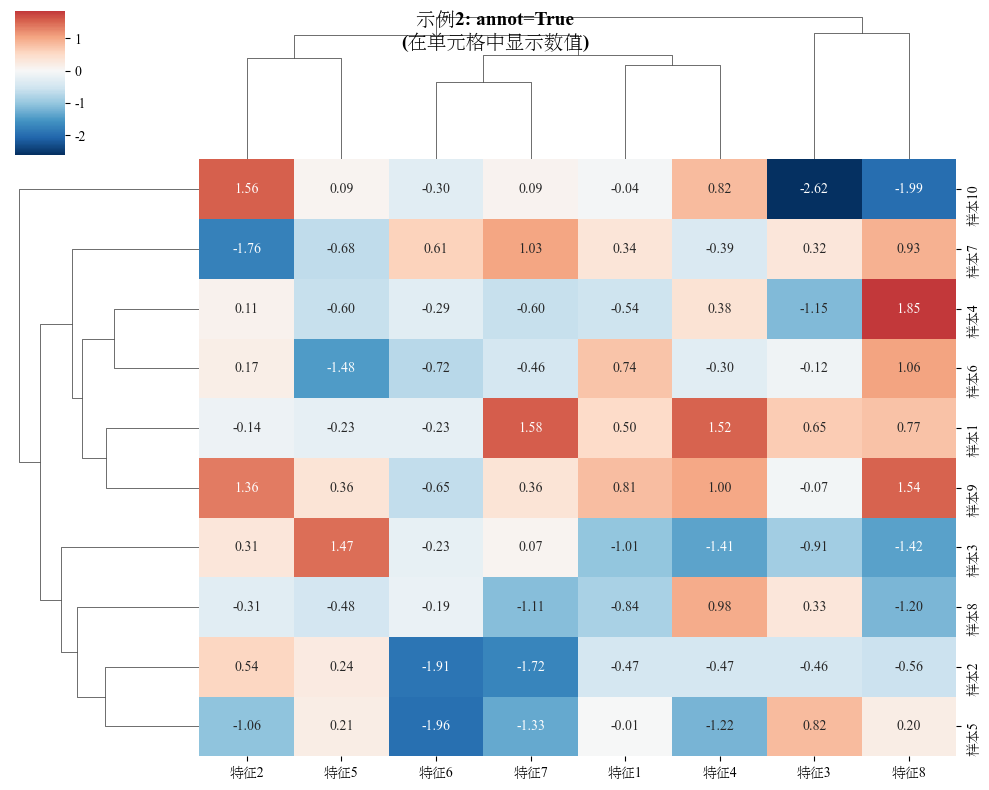


# ========== 示例 3：dendrogram_ratio - 树状图比例 ==========


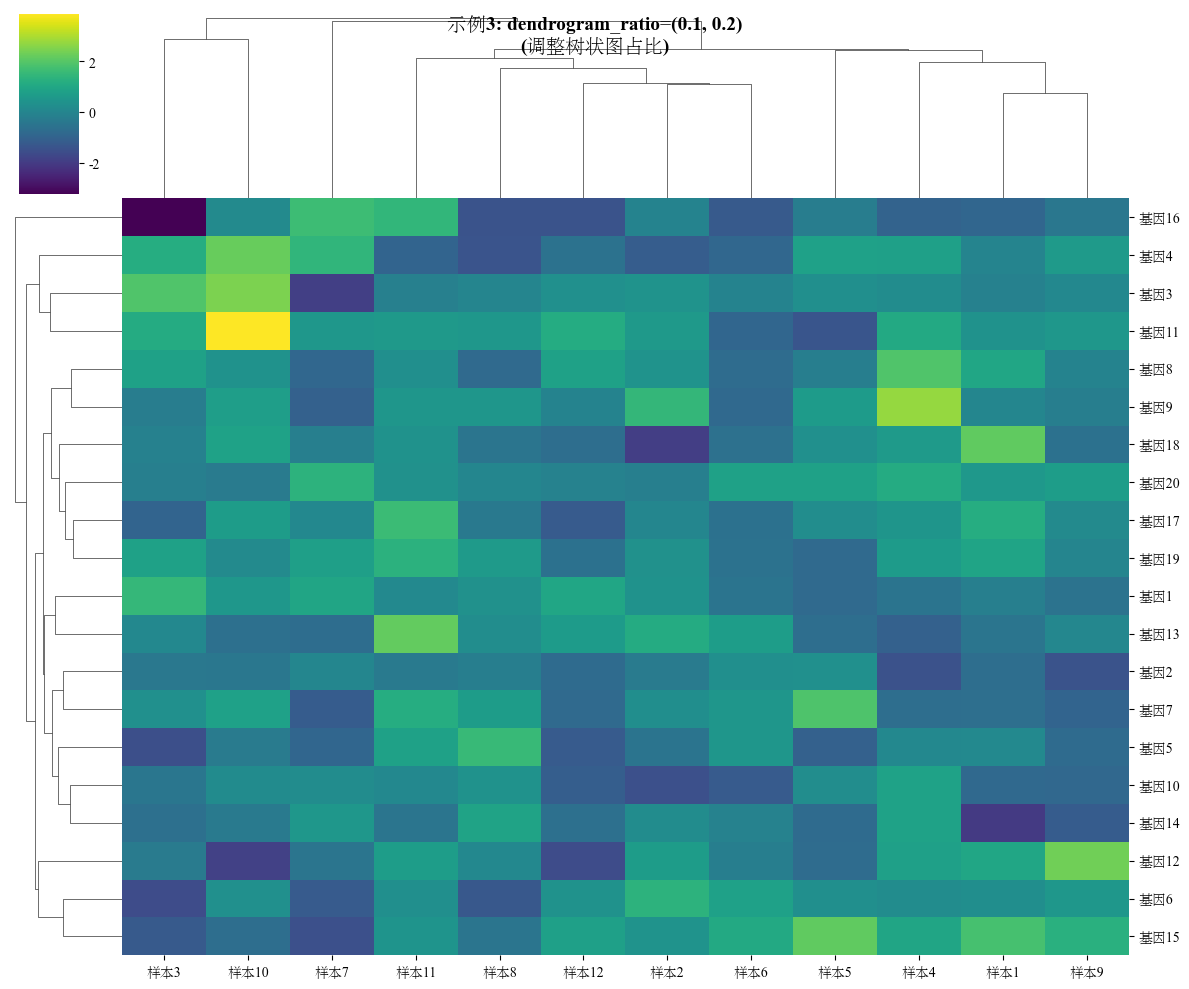


# ========== 示例 4：row_cluster - 只聚类行 ==========


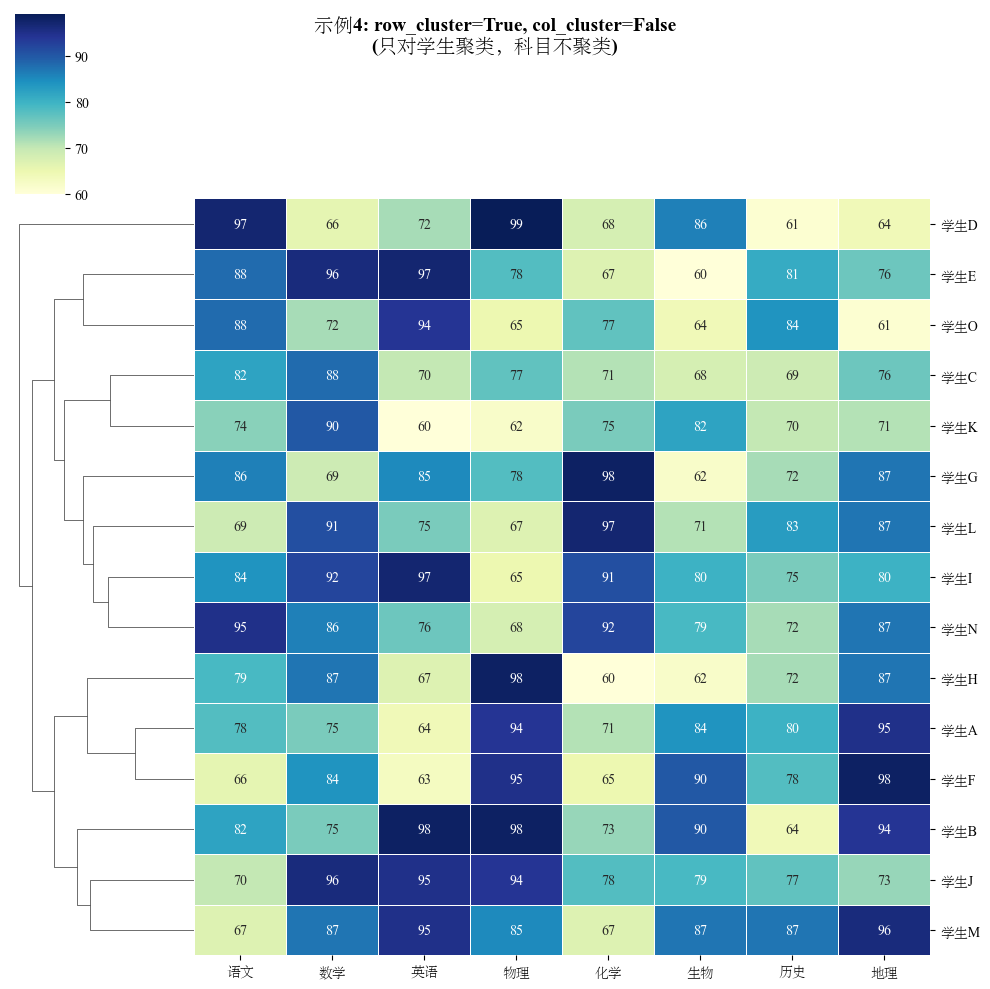


# ========== 示例 5：col_cluster - 只聚类列 ==========


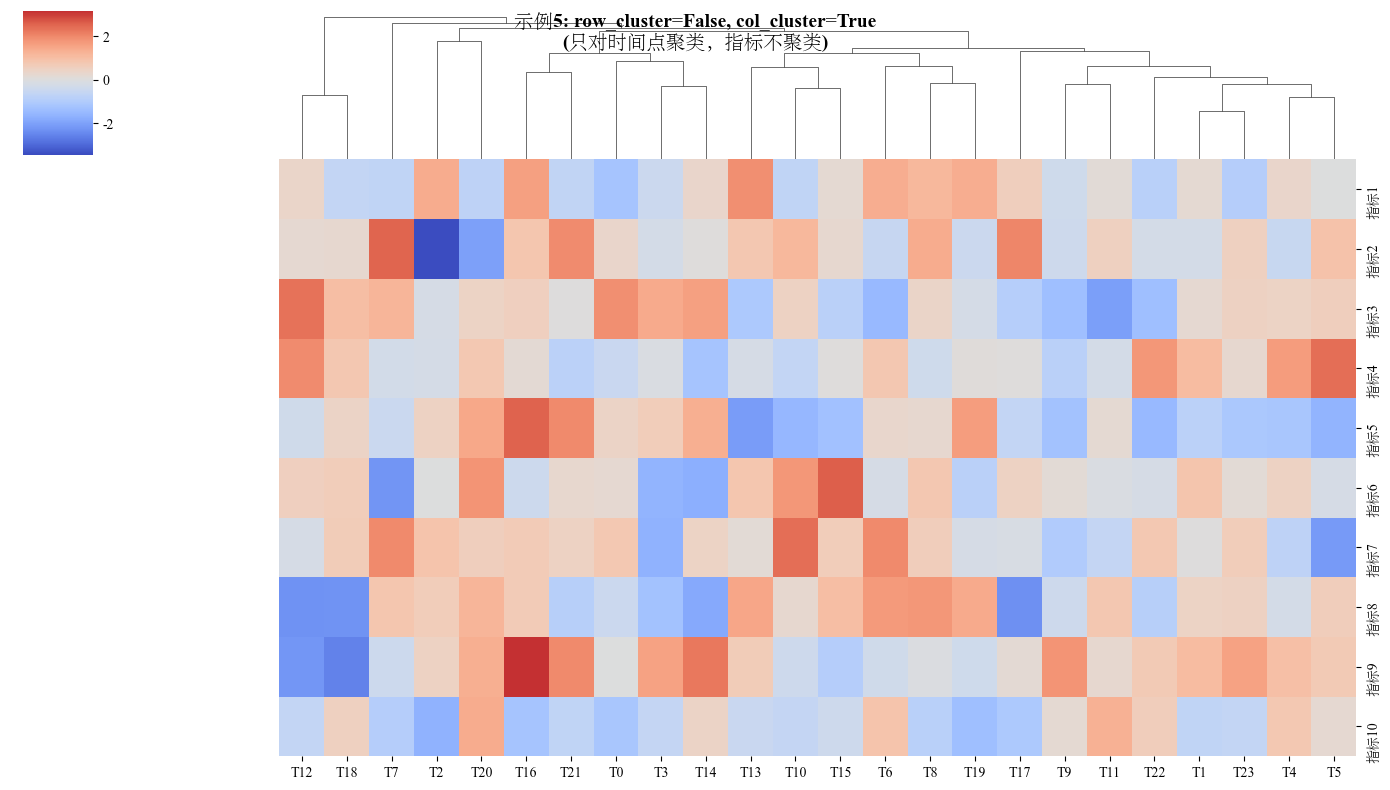

In [10]:
# ==================== 第一部分：基础用法 ====================
print("\n" + "=" * 80)  # 打印换行和80个等号，创建分隔线，标记第一部分开始
print("【第一部分】基础用法")  # 打印部分标题，说明展示clustermap基础用法
print("=" * 80)  # 打印80个等号，结束分隔线

# ========== 示例 1：最基础的 clustermap ==========
print("\n# ========== 示例 1：基础 clustermap ==========")  # 打印示例标题，说明基础clustermap
g1 = sns.clustermap(basic_data,
                    figsize=(10, 8))  # 绘制基础clustermap，使用basic_data数据集
# 参数说明：basic_data为10x8随机矩阵，figsize=(10, 8)设置画布尺寸为10x8英寸
g1.fig.suptitle(
    '示例1: 基础clustermap\n(自动聚类 + 树状图 + 热图)',  # 设置画布标题，说明基础功能
    fontsize=14,  # 标题字体大小14，适中醒目
    fontweight='bold',  # 标题粗体，增强视觉效果
    y=0.98)  # 标题位置稍低于画布顶部，避免遮挡
plt.show()  # 显示图表，渲染基础clustermap，包含行和列的树状图及热图

# ========== 示例 2：显示数值 - annot参数 ==========
print("\n# ========== 示例 2：annot参数 - 显示数值 ==========")  # 打印示例标题，说明annot参数用法
g2 = sns.clustermap(
    basic_data,  # 使用basic_data数据集
    annot=True,  # 显示单元格数值
    fmt='.2f',  # 数值保留2位小数
    figsize=(10, 8),  # 设置画布尺寸为10x8英寸
    cmap='RdBu_r',  # 使用红蓝反转调色板，突出正负值
    center=0)  # 设置颜色中心点为0，适合正态分布数据
g2.fig.suptitle(
    '示例2: annot=True\n(在单元格中显示数值)',  # 设置标题，说明数值显示效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染带数值的clustermap

# ========== 示例 3：调整树状图大小 - dendrogram_ratio参数 ==========
print("\n# ========== 示例 3：dendrogram_ratio - 树状图比例 =========="
      )  # 打印示例标题，说明树状图比例调整
g3 = sns.clustermap(
    gene_expression,  # 使用gene_expression数据集，20x12基因表达矩阵
    figsize=(12, 10),  # 设置画布尺寸为12x10英寸，适应较大矩阵
    dendrogram_ratio=(.1, .2),  # 设置行树宽度占比0.1，列树高度占比0.2
    cmap='viridis')  # 使用viridis调色板，感知均匀渐变
g3.fig.suptitle(
    '示例3: dendrogram_ratio=(0.1, 0.2)\n(调整树状图占比)',  # 设置标题，说明树状图比例效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染调整树状图比例的clustermap

# ========== 示例 4：row_cluster参数 - 只聚类行 ==========
print("\n# ========== 示例 4：row_cluster - 只聚类行 ==========")  # 打印示例标题，说明只聚类行
g4 = sns.clustermap(
    scores,  # 使用scores数据集，15x8学生成绩矩阵
    row_cluster=True,  # 启用行聚类，对学生进行聚类
    col_cluster=False,  # 禁用列聚类，保持科目顺序不变
    figsize=(10, 10),  # 设置画布尺寸为10x10英寸，适应行聚类
    cmap='YlGnBu',  # 使用黄绿蓝调色板，突出成绩高低
    annot=True,  # 显示单元格数值
    fmt='d',  # 数值格式为整数，适合成绩数据
    linewidths=0.5)  # 设置网格线宽度为0.5，细腻显示
g4.fig.suptitle(
    '示例4: row_cluster=True, col_cluster=False\n(只对学生聚类，科目不聚类)',  # 设置标题，说明行聚类效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染仅行聚类的clustermap

# ========== 示例 5：col_cluster参数 - 只聚类列 ==========
print("\n# ========== 示例 5：col_cluster - 只聚类列 ==========")  # 打印示例标题，说明只聚类列
g5 = sns.clustermap(
    time_series,  # 使用time_series数据集，10x24时间序列矩阵
    row_cluster=False,  # 禁用行聚类，保持指标顺序不变
    col_cluster=True,  # 启用列聚类，对时间点进行聚类
    figsize=(14, 8),  # 设置画布尺寸为14x8英寸，适应宽矩阵
    cmap='coolwarm',  # 使用红蓝渐变调色板，突出正负值
    center=0)  # 设置颜色中心点为0，适合时间序列数据
g5.fig.suptitle(
    '示例5: row_cluster=False, col_cluster=True\n(只对时间点聚类，指标不聚类)',  # 设置标题，说明列聚类效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染仅列聚类的clustermap


【第二部分】聚类方法与距离度量

# ========== 示例 6：method='average' - 平均连接 ==========


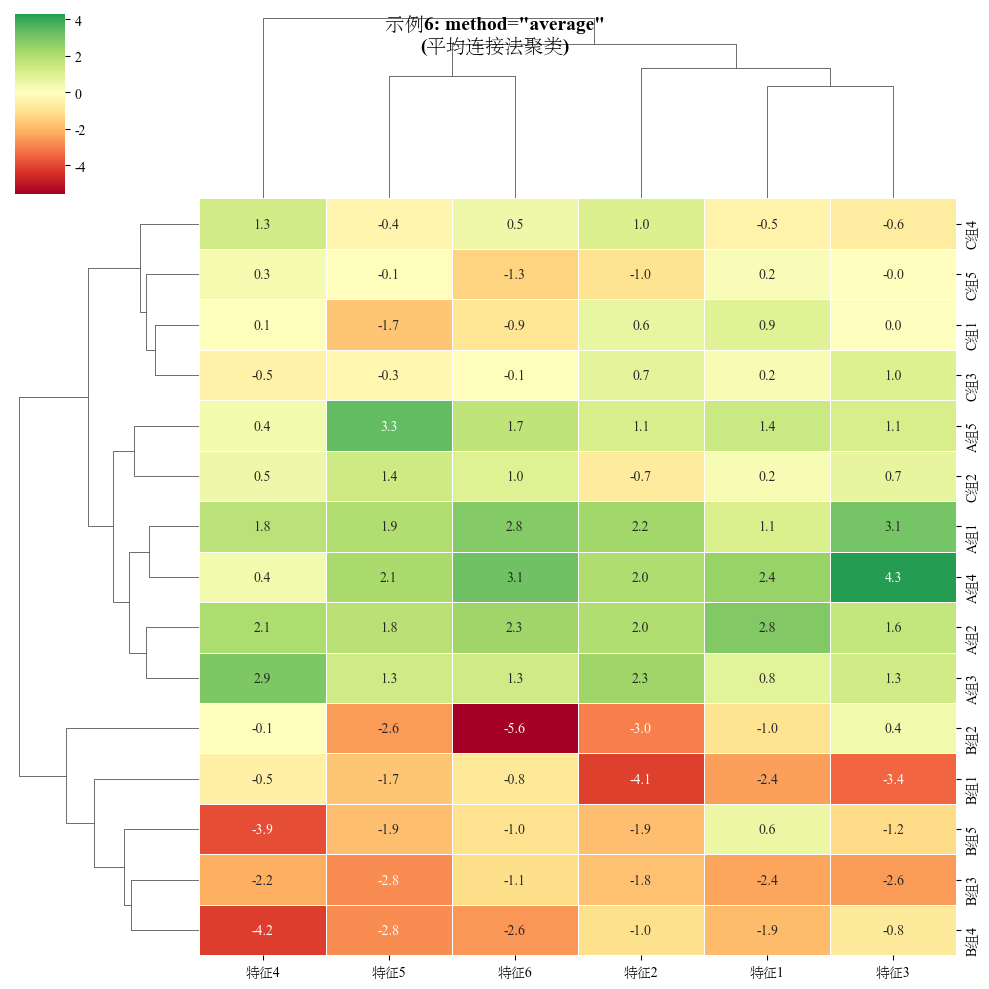


# ========== 示例 7：method='complete' - 完全连接 ==========


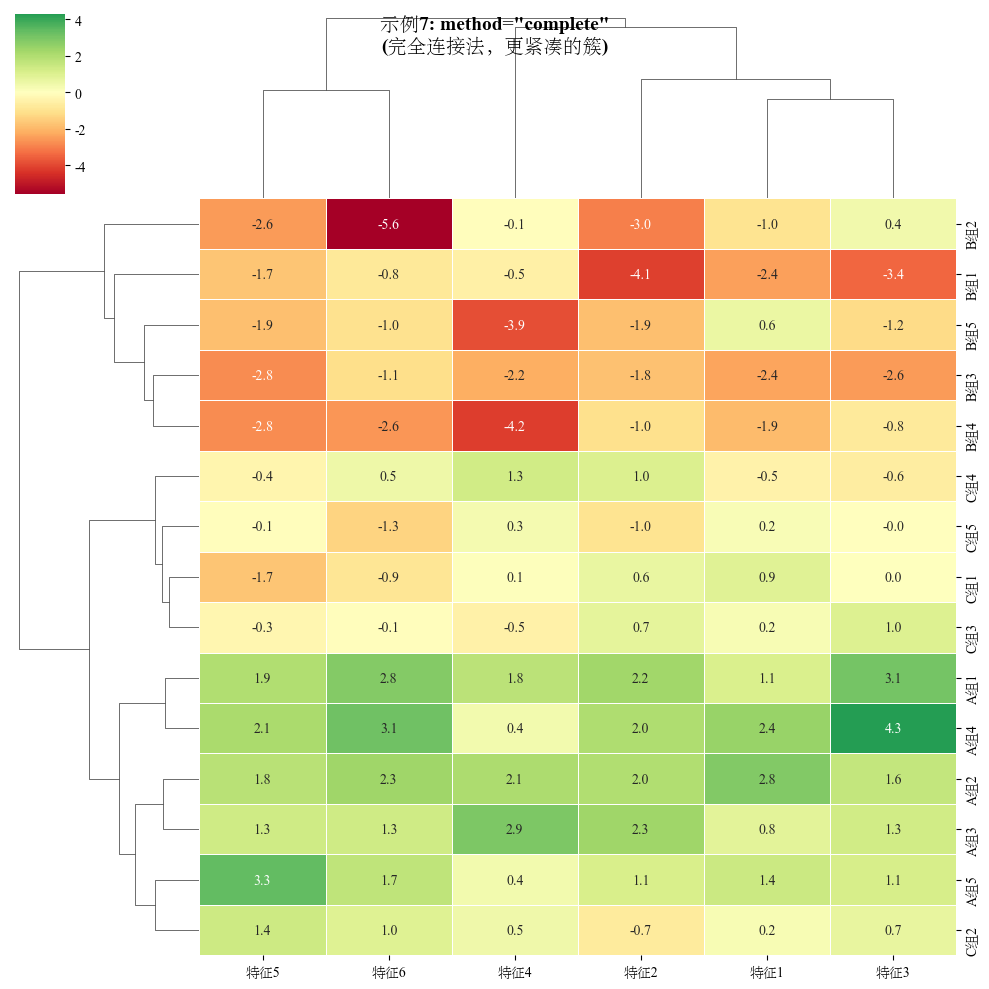


# ========== 示例 8：method='ward' - 沃德方差最小化 ==========


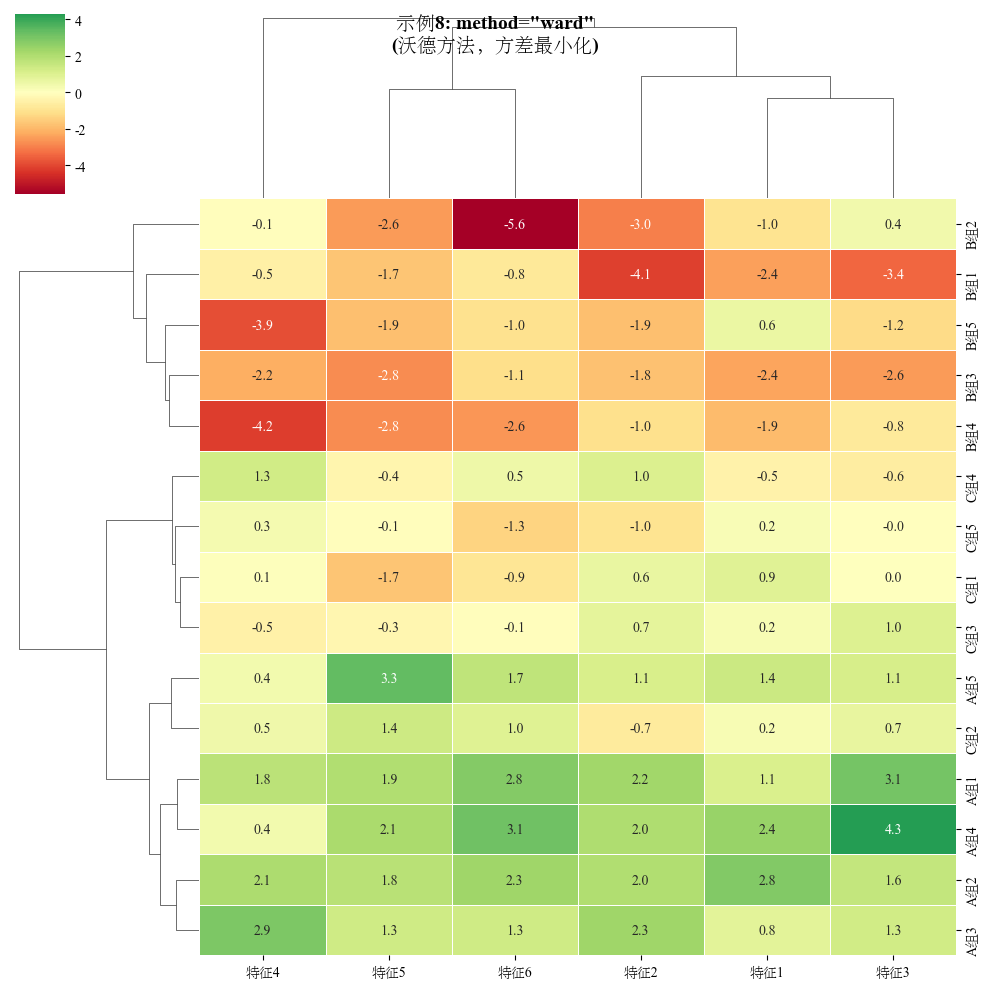


# ========== 示例 9：metric='euclidean' - 欧氏距离 ==========


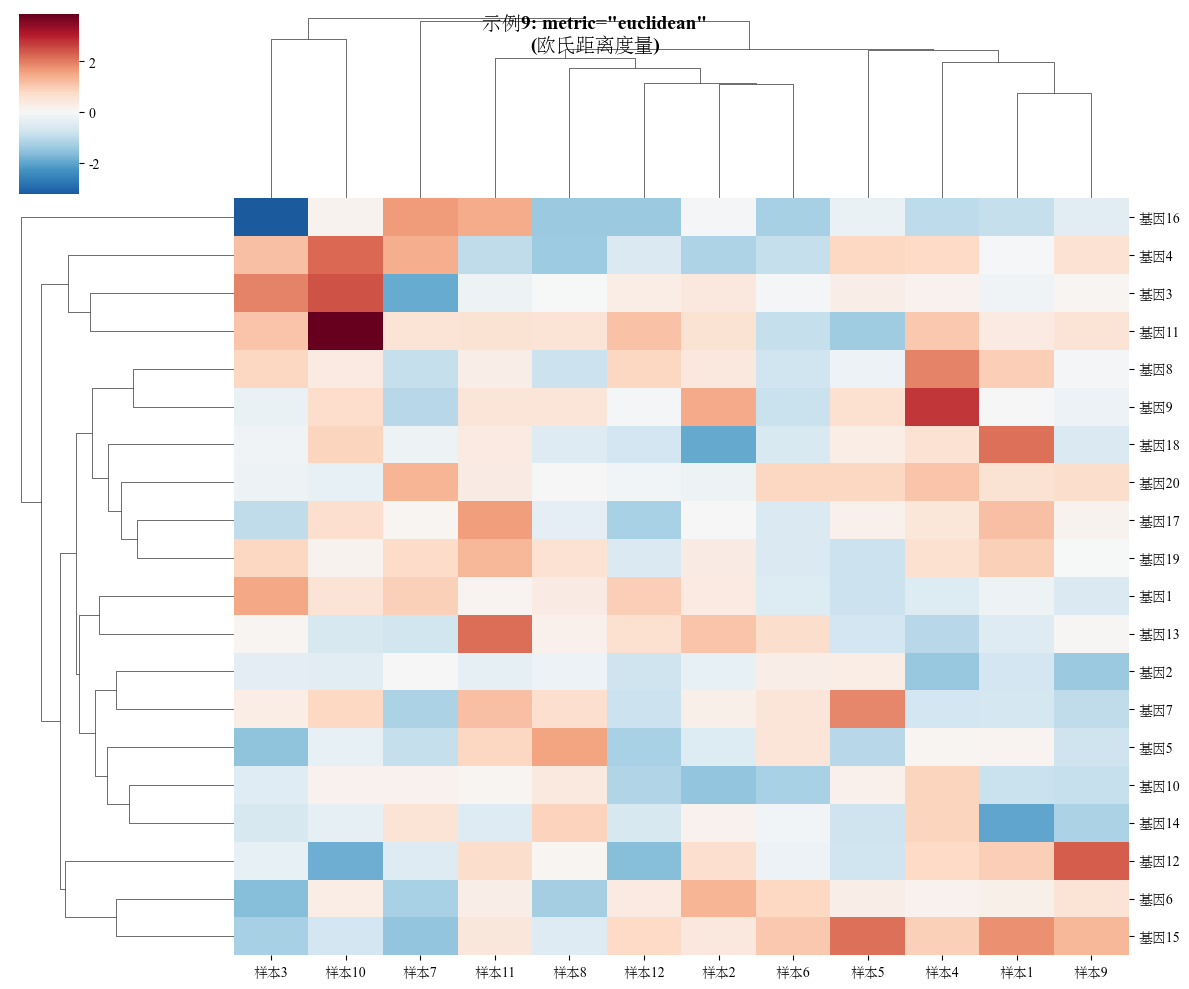


# ========== 示例 10：metric='correlation' - 相关距离 ==========


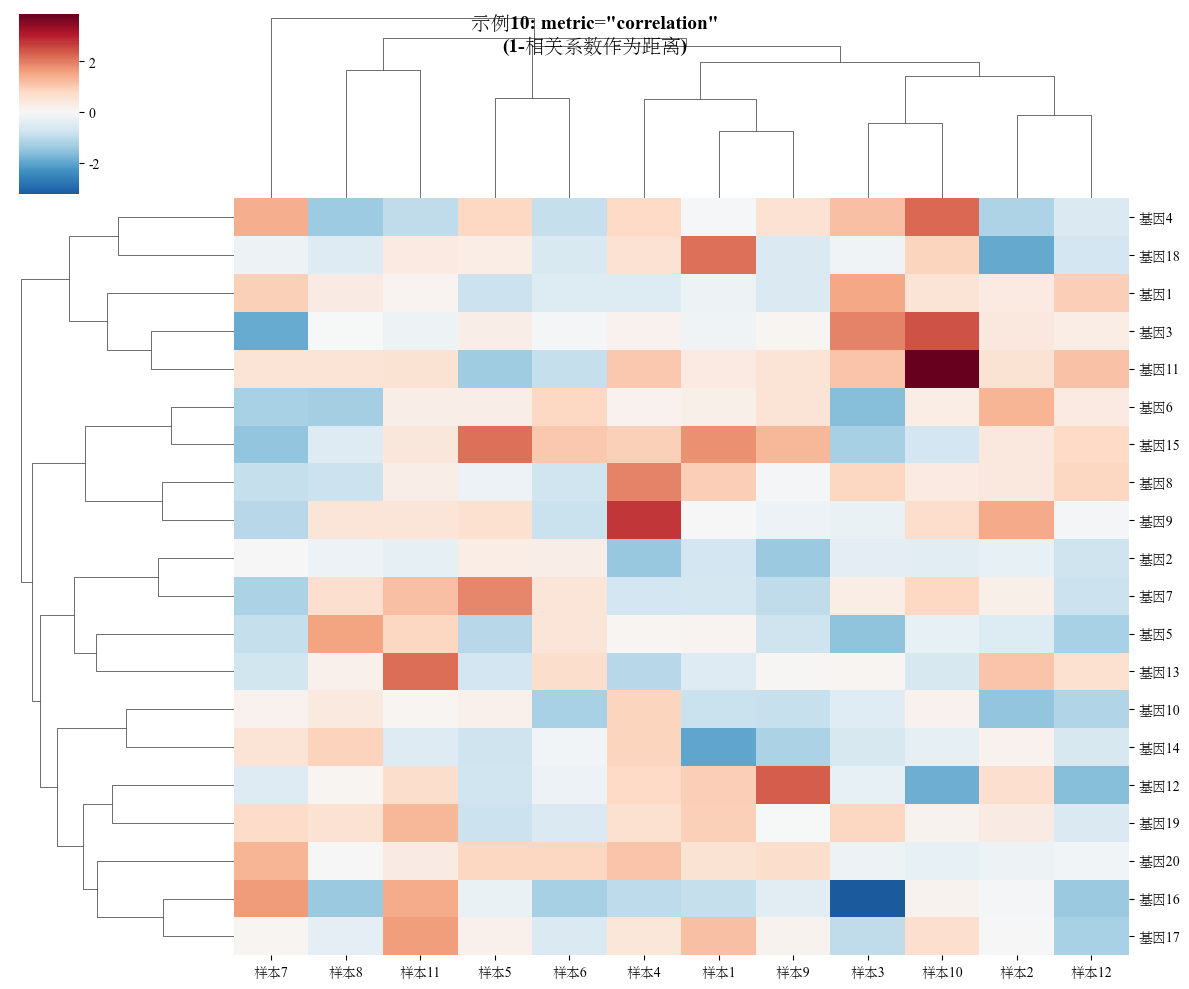


# ========== 示例 11：metric='cityblock' - 曼哈顿距离 ==========


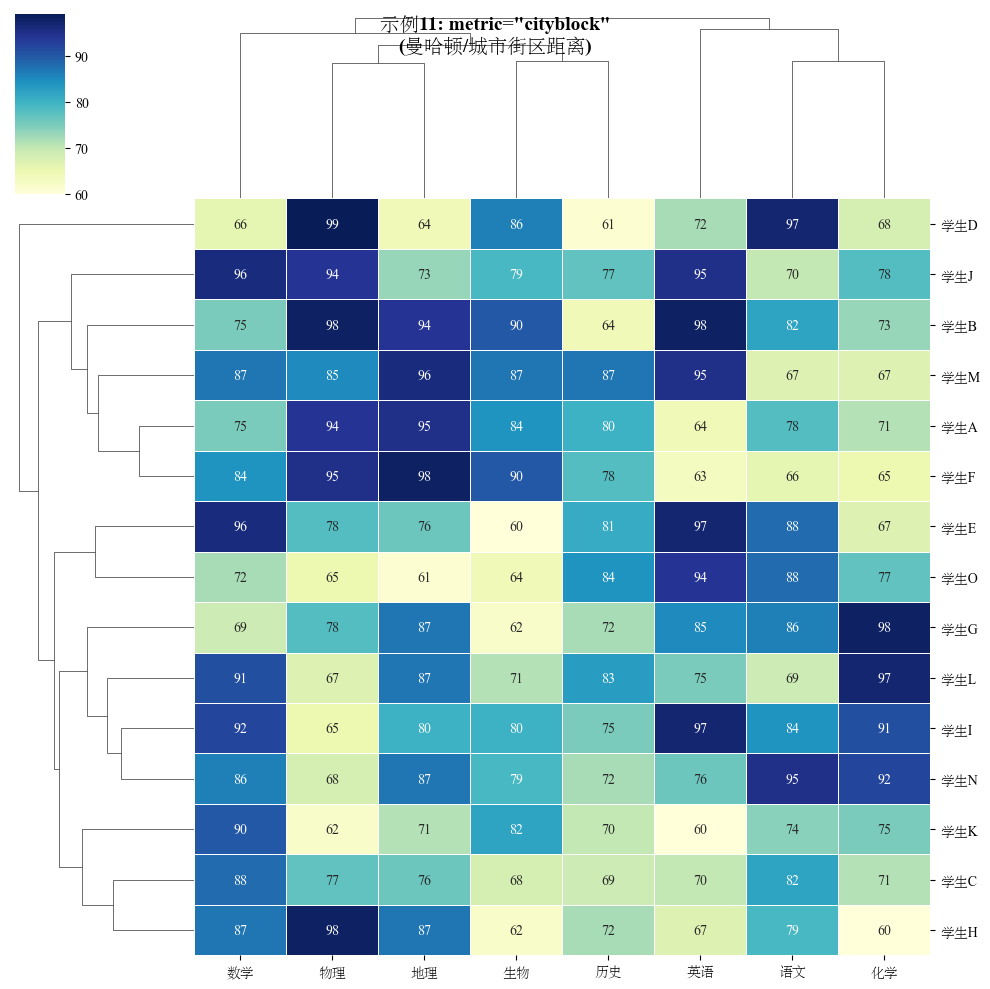


【第三部分】数据标准化

# ========== 示例 12：standard_scale=1 - 列标准化 ==========


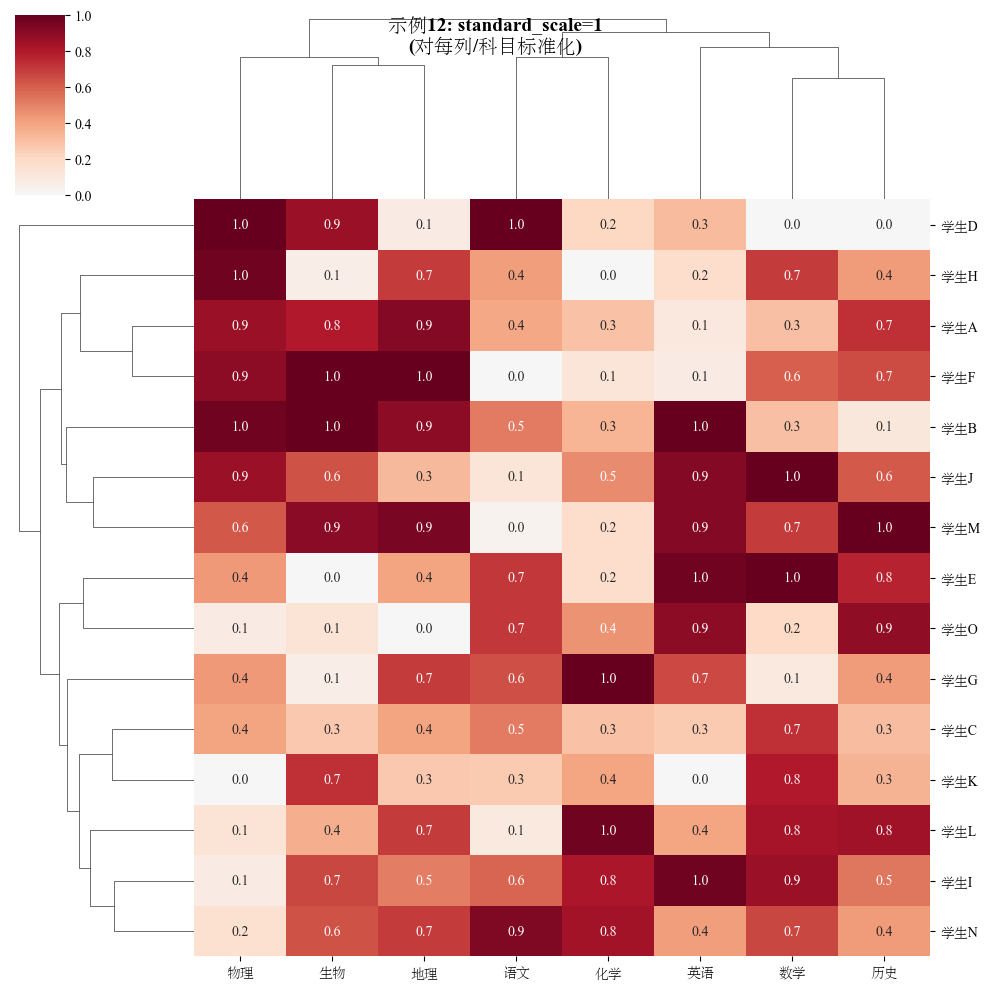


# ========== 示例 13：standard_scale=0 - 行标准化 ==========


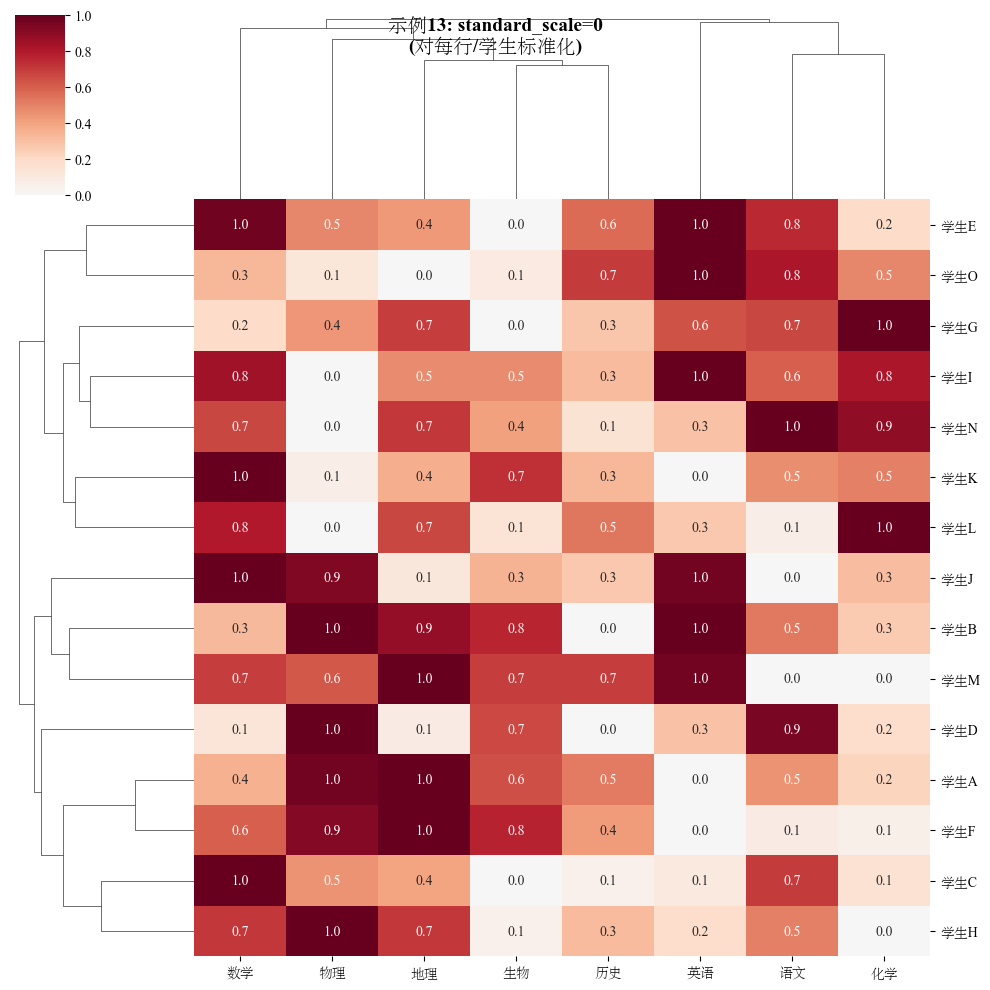


# ========== 示例 14：z_score=1 - 列Z分数 ==========


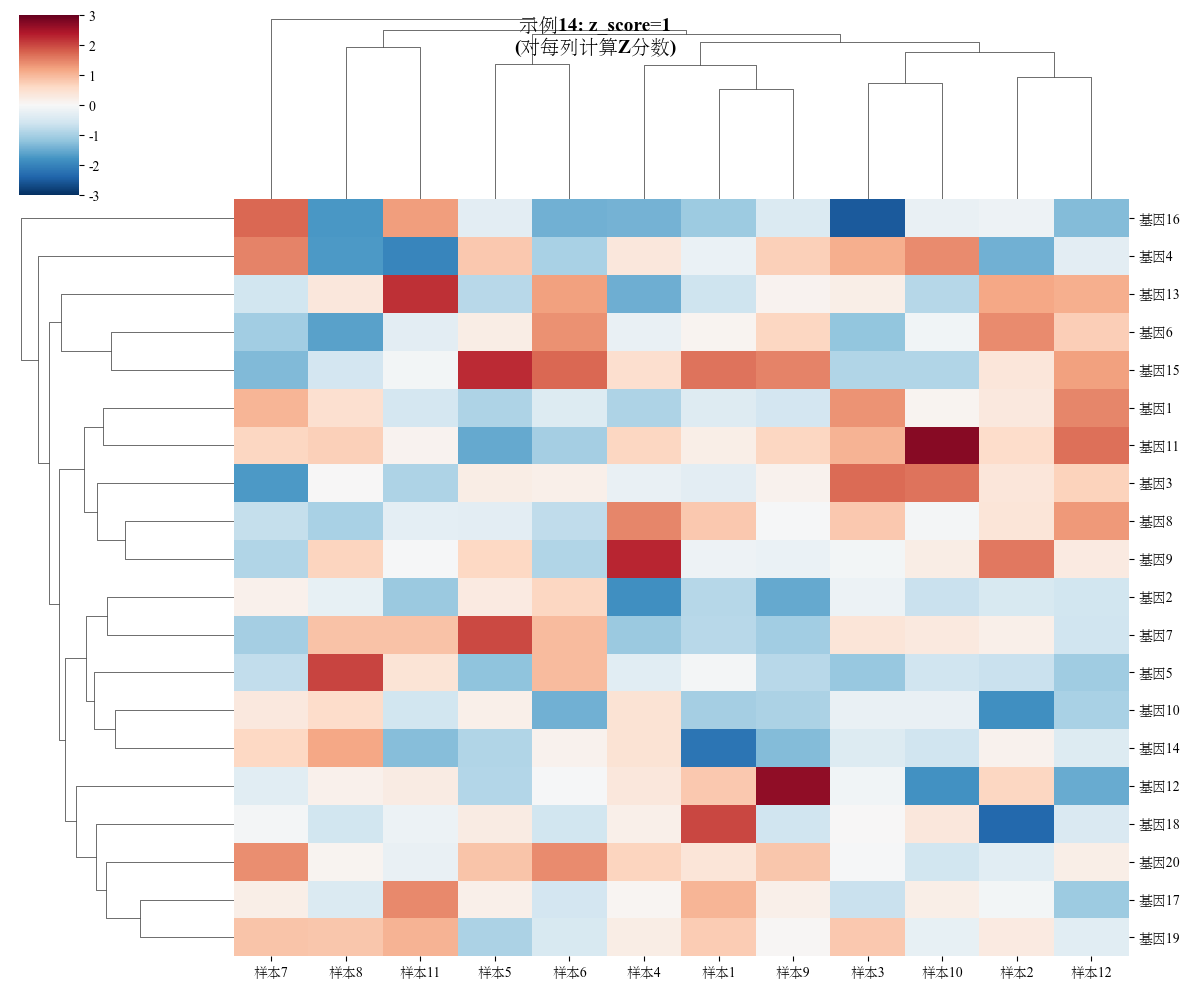


# ========== 示例 15：z_score=0 - 行Z分数 ==========


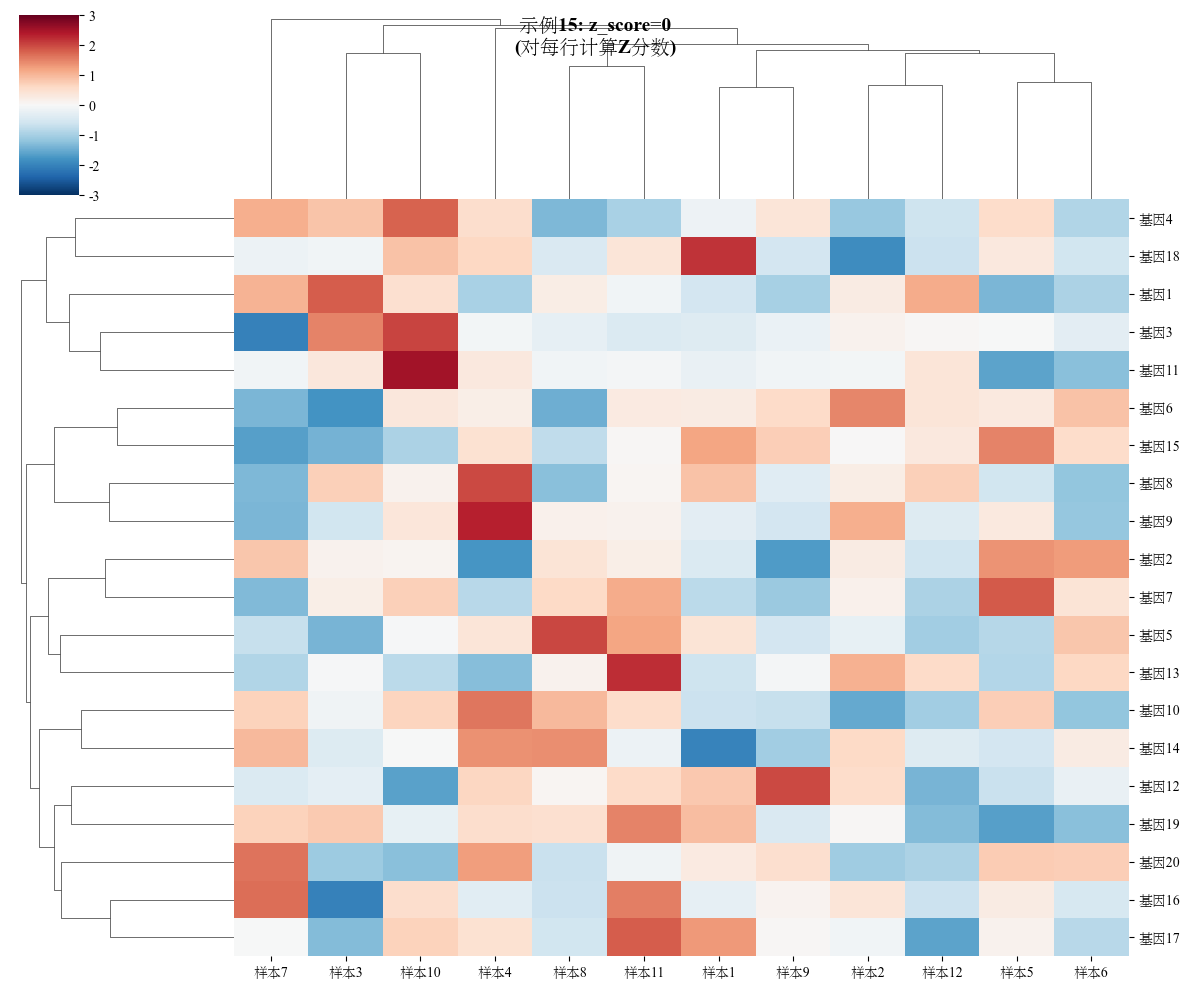

In [11]:
# ==================== 第二部分：聚类方法与距离度量 ====================
print("\n" + "=" * 80)  # 打印换行和80个等号，创建分隔线，标记第二部分开始
print("【第二部分】聚类方法与距离度量")  # 打印部分标题，说明展示聚类方法与距离度量
print("=" * 80)  # 打印80个等号，结束分隔线

# ========== 示例 6：method参数 - 平均连接 ==========
print(
    "\n# ========== 示例 6：method='average' - 平均连接 ==========")  # 打印示例标题，说明平均连接法
g6 = sns.clustermap(
    group_data,  # 使用group_data数据集，15x6含分组特征
    method='average',  # 使用平均连接法（UPGMA）进行层次聚类
    figsize=(10, 10),  # 设置画布尺寸为10x10英寸
    cmap='RdYlGn',  # 使用红黄绿调色板，突出数据分组
    center=0,  # 设置颜色中心点为0，适合正负值
    annot=True,  # 显示单元格数值
    fmt='.1f',  # 数值保留1位小数
    linewidths=0.5)  # 设置网格线宽度为0.5，细腻显示
g6.fig.suptitle(
    '示例6: method="average"\n(平均连接法聚类)',  # 设置标题，说明平均连接法效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染平均连接法clustermap

# ========== 示例 7：method参数 - 完全连接 ==========
print("\n# ========== 示例 7：method='complete' - 完全连接 =========="
      )  # 打印示例标题，说明完全连接法
g7 = sns.clustermap(
    group_data,  # 使用group_data数据集
    method='complete',  # 使用完全连接法，生成更紧凑的簇
    figsize=(10, 10),  # 设置画布尺寸为10x10英寸
    cmap='RdYlGn',  # 使用红黄绿调色板
    center=0,  # 设置颜色中心点为0
    annot=True,  # 显示单元格数值
    fmt='.1f',  # 数值保留1位小数
    linewidths=0.5)  # 设置网格线宽度为0.5
g7.fig.suptitle(
    '示例7: method="complete"\n(完全连接法，更紧凑的簇)',  # 设置标题，说明完全连接法效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染完全连接法clustermap

# ========== 示例 8：method参数 - 沃德方差最小化 ==========
print("\n# ========== 示例 8：method='ward' - 沃德方差最小化 =========="
      )  # 打印示例标题，说明Ward方法
g8 = sns.clustermap(
    group_data,  # 使用group_data数据集
    method='ward',  # 使用Ward方法，基于方差最小化聚类
    figsize=(10, 10),  # 设置画布尺寸为10x10英寸
    cmap='RdYlGn',  # 使用红黄绿调色板
    center=0,  # 设置颜色中心点为0
    annot=True,  # 显示单元格数值
    fmt='.1f',  # 数值保留1位小数
    linewidths=0.5)  # 设置网格线宽度为0.5
g8.fig.suptitle(
    '示例8: method="ward"\n(沃德方法，方差最小化)',  # 设置标题，说明Ward方法效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染Ward方法clustermap

# ========== 示例 9：metric参数 - 欧氏距离 ==========
print("\n# ========== 示例 9：metric='euclidean' - 欧氏距离 =========="
      )  # 打印示例标题，说明欧氏距离
g9 = sns.clustermap(
    gene_expression,  # 使用gene_expression数据集，20x12基因表达矩阵
    metric='euclidean',  # 使用欧氏距离度量点间距离
    method='average',  # 使用平均连接法
    figsize=(12, 10),  # 设置画布尺寸为12x10英寸，适应较大矩阵
    cmap='RdBu_r',  # 使用红蓝反转调色板，突出正负值
    center=0)  # 设置颜色中心点为0
g9.fig.suptitle(
    '示例9: metric="euclidean"\n(欧氏距离度量)',  # 设置标题，说明欧氏距离效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染欧氏距离clustermap

# ========== 示例 10：metric参数 - 相关距离 ==========
print("\n# ========== 示例 10：metric='correlation' - 相关距离 =========="
      )  # 打印示例标题，说明相关距离
g10 = sns.clustermap(
    gene_expression,  # 使用gene_expression数据集
    metric='correlation',  # 使用相关距离（1-相关系数）度量
    method='average',  # 使用平均连接法
    figsize=(12, 10),  # 设置画布尺寸为12x10英寸
    cmap='RdBu_r',  # 使用红蓝反转调色板
    center=0)  # 设置颜色中心点为0
g10.fig.suptitle(
    '示例10: metric="correlation"\n(1-相关系数作为距离)',  # 设置标题，说明相关距离效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染相关距离clustermap

# ========== 示例 11：metric参数 - 曼哈顿距离 ==========
print("\n# ========== 示例 11：metric='cityblock' - 曼哈顿距离 =========="
      )  # 打印示例标题，说明曼哈顿距离
g11 = sns.clustermap(
    scores,  # 使用scores数据集，15x8学生成绩矩阵
    metric='cityblock',  # 使用曼哈顿（城市街区）距离度量
    method='average',  # 使用平均连接法
    figsize=(10, 10),  # 设置画布尺寸为10x10英寸
    cmap='YlGnBu',  # 使用黄绿蓝调色板，突出成绩高低
    annot=True,  # 显示单元格数值
    fmt='d',  # 数值格式为整数，适合成绩
    linewidths=0.5)  # 设置网格线宽度为0.5
g11.fig.suptitle(
    '示例11: metric="cityblock"\n(曼哈顿/城市街区距离)',  # 设置标题，说明曼哈顿距离效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染曼哈顿距离clustermap

# ==================== 第三部分：数据标准化 ====================
print("\n" + "=" * 80)  # 打印换行和80个等号，创建分隔线，标记第三部分开始
print("【第三部分】数据标准化")  # 打印部分标题，说明展示数据标准化
print("=" * 80)  # 打印80个等号，结束分隔线

# ========== 示例 12：standard_scale参数 - 列标准化 ==========
print(
    "\n# ========== 示例 12：standard_scale=1 - 列标准化 ==========")  # 打印示例标题，说明列标准化
g12 = sns.clustermap(
    scores,  # 使用scores数据集
    standard_scale=1,  # 对每列（科目）进行标准化（均值0，标准差1）
    figsize=(10, 10),  # 设置画布尺寸为10x10英寸
    cmap='RdBu_r',  # 使用红蓝反转调色板，突出标准化值
    center=0,  # 设置颜色中心点为0
    annot=True,  # 显示单元格数值
    fmt='.1f')  # 数值保留1位小数
g12.fig.suptitle(
    '示例12: standard_scale=1\n(对每列/科目标准化)',  # 设置标题，说明列标准化效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染列标准化clustermap

# ========== 示例 13：standard_scale参数 - 行标准化 ==========
print(
    "\n# ========== 示例 13：standard_scale=0 - 行标准化 ==========")  # 打印示例标题，说明行标准化
g13 = sns.clustermap(
    scores,  # 使用scores数据集
    standard_scale=0,  # 对每行（学生）进行标准化（均值0，标准差1）
    figsize=(10, 10),  # 设置画布尺寸为10x10英寸
    cmap='RdBu_r',  # 使用红蓝反转调色板
    center=0,  # 设置颜色中心点为0
    annot=True,  # 显示单元格数值
    fmt='.1f')  # 数值保留1位小数
g13.fig.suptitle(
    '示例13: standard_scale=0\n(对每行/学生标准化)',  # 设置标题，说明行标准化效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染行标准化clustermap

# ========== 示例 14：z_score参数 - Z分数标准化(列) ==========
print("\n# ========== 示例 14：z_score=1 - 列Z分数 ==========")  # 打印示例标题，说明列Z分数标准化
g14 = sns.clustermap(
    gene_expression,  # 使用gene_expression数据集
    z_score=1,  # 对每列（样本）进行Z分数标准化（均值0，标准差1）
    figsize=(12, 10),  # 设置画布尺寸为12x10英寸
    cmap='RdBu_r',  # 使用红蓝反转调色板
    center=0,  # 设置颜色中心点为0
    vmin=-3,  # 设置颜色映射最小值为-3，限制值域
    vmax=3)  # 设置颜色映射最大值为3，限制值域
g14.fig.suptitle(
    '示例14: z_score=1\n(对每列计算Z分数)',  # 设置标题，说明列Z分数效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染列Z分数clustermap

# ========== 示例 15：z_score参数 - Z分数标准化(行) ==========
print("\n# ========== 示例 15：z_score=0 - 行Z分数 ==========")  # 打印示例标题，说明行Z分数标准化
g15 = sns.clustermap(
    gene_expression,  # 使用gene_expression数据集
    z_score=0,  # 对每行（基因）进行Z分数标准化（均值0，标准差1）
    figsize=(12, 10),  # 设置画布尺寸为12x10英寸
    cmap='RdBu_r',  # 使用红蓝反转调色板
    center=0,  # 设置颜色中心点为0
    vmin=-3,  # 设置颜色映射最小值为-3
    vmax=3)  # 设置颜色映射最大值为3
g15.fig.suptitle(
    '示例15: z_score=0\n(对每行计算Z分数)',  # 设置标题，说明行Z分数效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染行Z分数clustermap


【第四部分】外观定制

# ========== 示例 16：cbar_pos - 颜色条位置 ==========


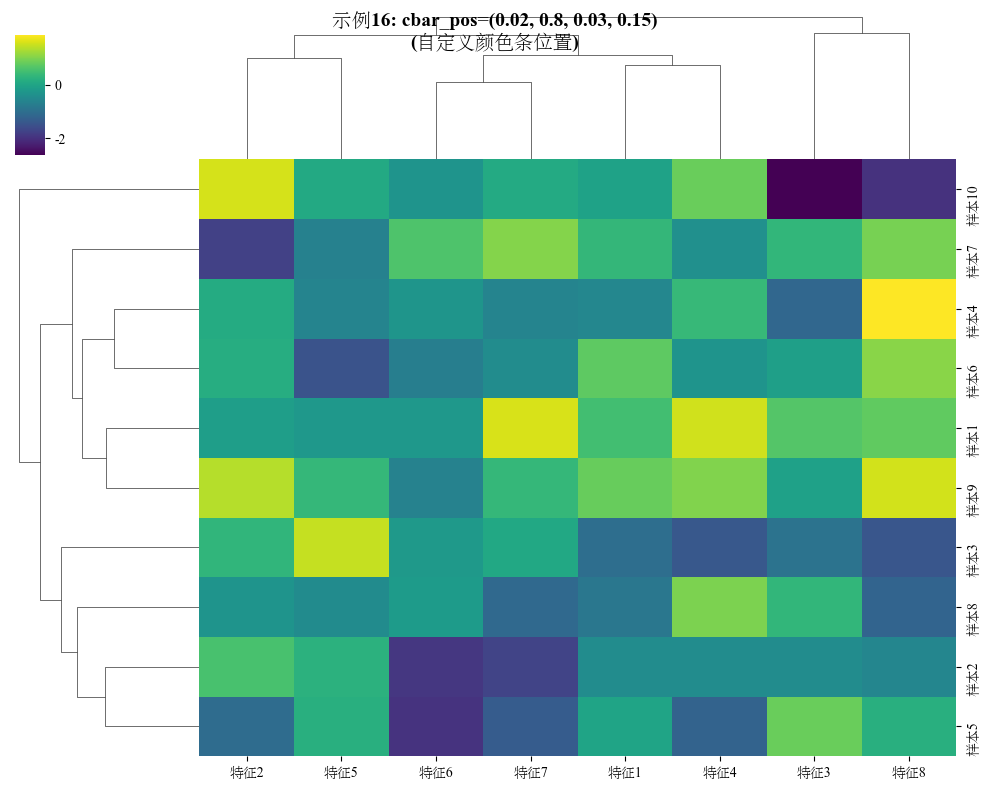


# ========== 示例 17：tree_kws - 树状图样式 ==========


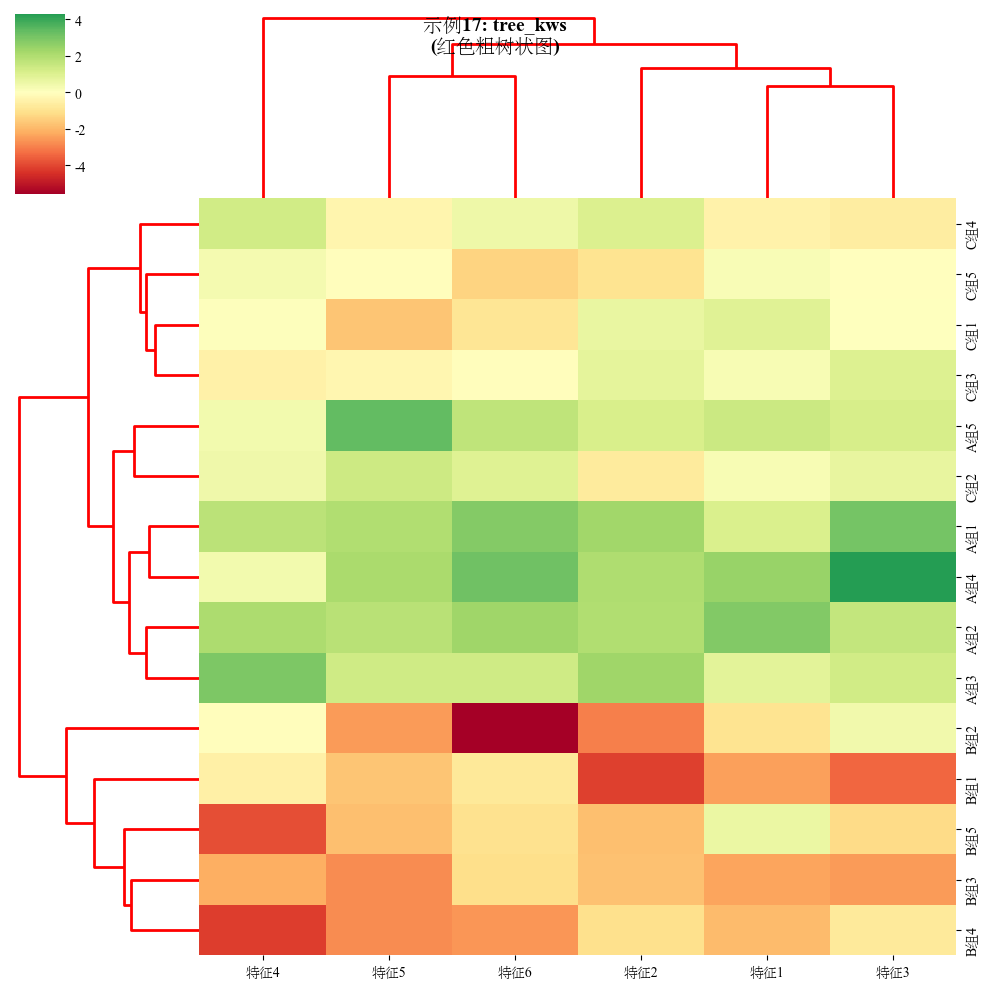


# ========== 示例 18：linewidths - 网格线样式 ==========


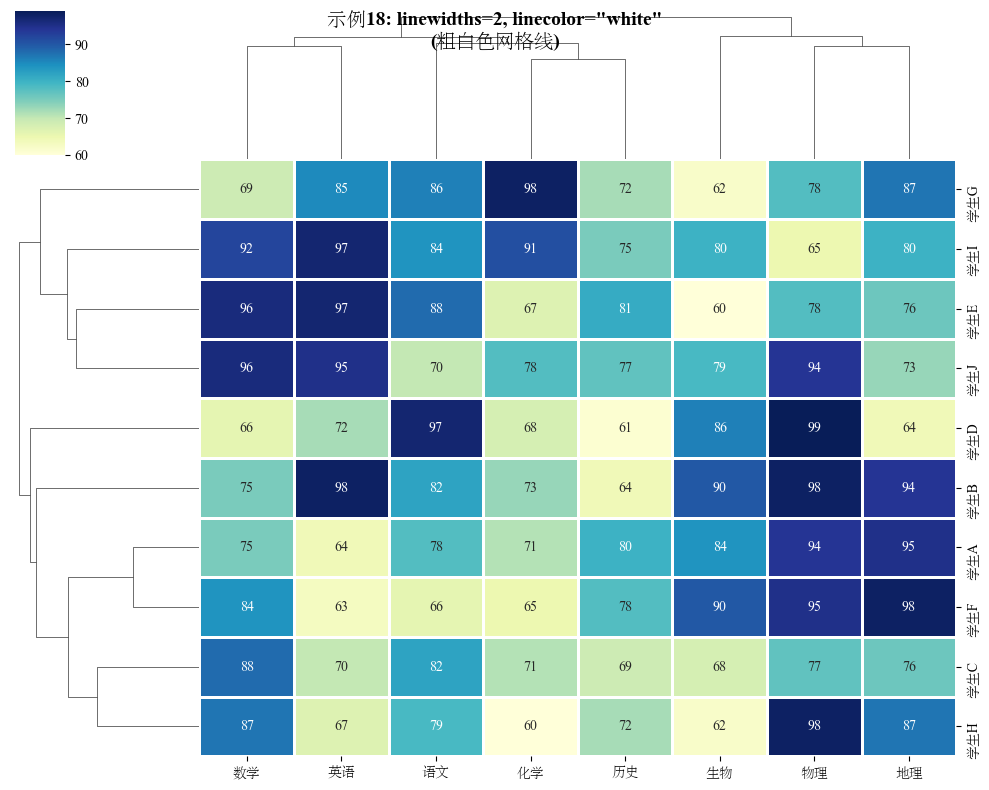


# ========== 示例 19：cbar_kws - 颜色条定制 ==========


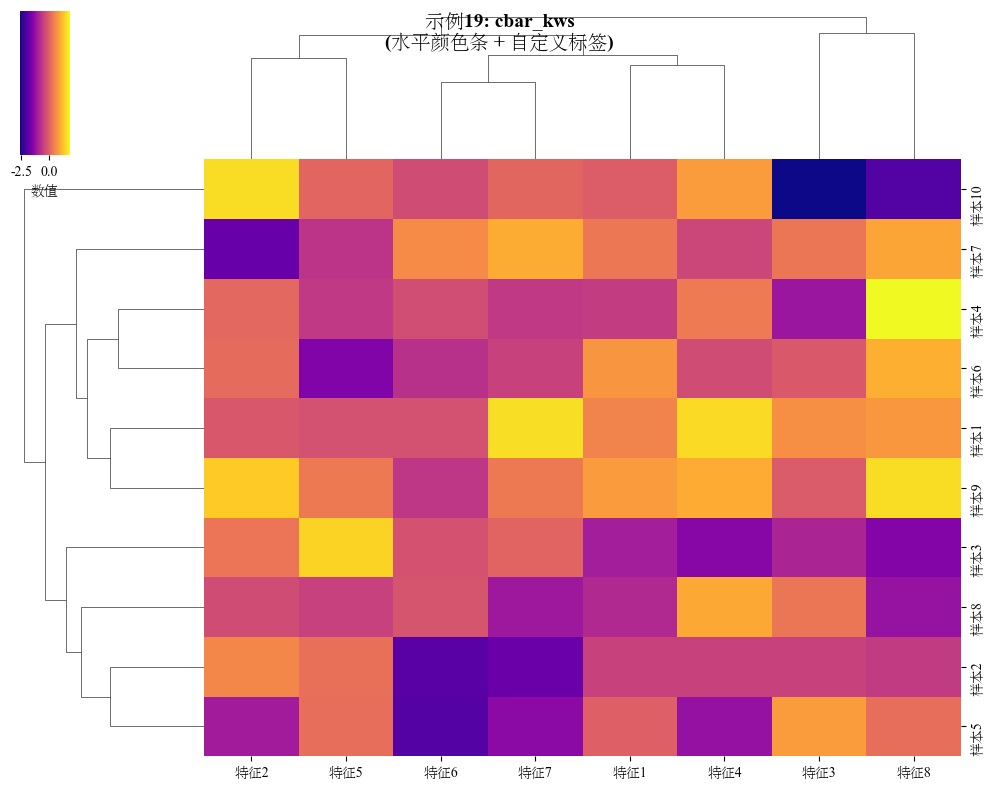


# ========== 示例 20：mask - 遮罩数据 ==========


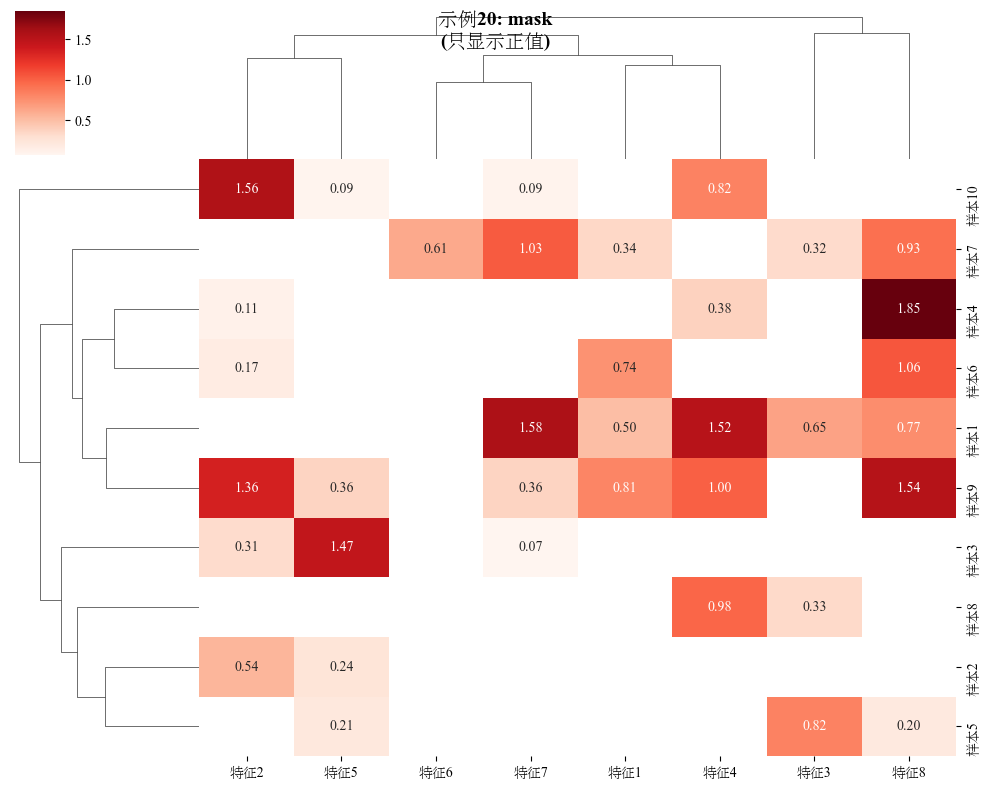

In [12]:
# ==================== 第四部分：外观定制 ====================
print("\n" + "=" * 80)  # 打印换行和80个等号，创建分隔线，标记第四部分开始
print("【第四部分】外观定制")  # 打印部分标题，说明展示clustermap外观定制
print("=" * 80)  # 打印80个等号，结束分隔线

# ========== 示例 16：cbar_pos参数 - 颜色条位置 ==========
print("\n# ========== 示例 16：cbar_pos - 颜色条位置 ==========")  # 打印示例标题，说明颜色条位置调整
g16 = sns.clustermap(
    basic_data,  # 使用basic_data数据集，10x8随机正态分布矩阵
    figsize=(10, 8),  # 设置画布尺寸为10x8英寸
    cbar_pos=(0.02, 0.8, 0.03,
              0.15),  # 设置颜色条位置和大小：x=0.02, y=0.8, 宽度=0.03, 高度=0.15
    cmap='viridis')  # 使用viridis调色板，感知均匀渐变
g16.fig.suptitle(
    '示例16: cbar_pos=(0.02, 0.8, 0.03, 0.15)\n(自定义颜色条位置)',  # 设置标题，说明颜色条位置效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染自定义颜色条位置的clustermap

# ========== 示例 17：tree_kws参数 - 树状图样式 ==========
print("\n# ========== 示例 17：tree_kws - 树状图样式 ==========")  # 打印示例标题，说明树状图样式调整
g17 = sns.clustermap(
    group_data,  # 使用group_data数据集，15x6含分组特征
    figsize=(10, 10),  # 设置画布尺寸为10x10英寸
    tree_kws={  # 设置树状图样式参数
        'linewidths': 2,  # 设置树状图线条宽度为2，突出显示
        'colors': 'red'  # 设置树状图线条颜色为红色，增强对比
    },
    cmap='RdYlGn',  # 使用红黄绿调色板，突出分组特征
    center=0)  # 设置颜色中心点为0，适合正负值
g17.fig.suptitle(
    '示例17: tree_kws\n(红色粗树状图)',  # 设置标题，说明树状图样式效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染红色粗树状图的clustermap

# ========== 示例 18：linewidths参数 - 网格线 ==========
print("\n# ========== 示例 18：linewidths - 网格线样式 ==========")  # 打印示例标题，说明网格线样式调整
g18 = sns.clustermap(
    scores.iloc[:10, :],  # 使用scores数据集的前10行，15x8学生成绩矩阵子集
    figsize=(10, 8),  # 设置画布尺寸为10x8英寸
    linewidths=2,  # 设置网格线宽度为2，突出网格
    linecolor='white',  # 设置网格线颜色为白色，增强美观
    cmap='YlGnBu',  # 使用黄绿蓝调色板，突出成绩高低
    annot=True,  # 显示单元格数值
    fmt='d')  # 数值格式为整数，适合成绩数据
g18.fig.suptitle(
    '示例18: linewidths=2, linecolor="white"\n(粗白色网格线)',  # 设置标题，说明网格线效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染粗白色网格线的clustermap

# ========== 示例 19：cbar_kws参数 - 颜色条定制 ==========
print("\n# ========== 示例 19：cbar_kws - 颜色条定制 ==========")  # 打印示例标题，说明颜色条定制
g19 = sns.clustermap(
    basic_data,  # 使用basic_data数据集
    figsize=(10, 8),  # 设置画布尺寸为10x8英寸
    cmap='plasma',  # 使用plasma调色板，紫粉黄渐变
    cbar_kws={  # 设置颜色条参数
        'label': '数值',  # 设置颜色条标签为“数值”
        'orientation': 'horizontal',  # 设置颜色条为水平显示
        'shrink': 0.8  # 缩小颜色条至80%长度，优化布局
    })
g19.fig.suptitle(
    '示例19: cbar_kws\n(水平颜色条 + 自定义标签)',  # 设置标题，说明颜色条定制效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染水平颜色条的clustermap

# ========== 示例 20：mask参数 - 遮罩部分数据 ==========
print("\n# ========== 示例 20：mask - 遮罩数据 ==========")  # 打印示例标题，说明数据遮罩
mask = basic_data < 0  # 创建遮罩，隐藏basic_data中小于0的值
g20 = sns.clustermap(
    basic_data,  # 使用basic_data数据集
    mask=mask,  # 应用遮罩，仅显示正值
    figsize=(10, 8),  # 设置画布尺寸为10x8英寸
    cmap='Reds',  # 使用红色系调色板，适合正值
    annot=True,  # 显示单元格数值
    fmt='.2f')  # 数值保留2位小数
g20.fig.suptitle(
    '示例20: mask\n(只显示正值)',  # 设置标题，说明遮罩效果
    fontsize=14,
    fontweight='bold',
    y=0.98)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染遮罩负值的clustermap


【第五部分】实际应用案例

# ========== 案例 1：基因表达分析 ==========


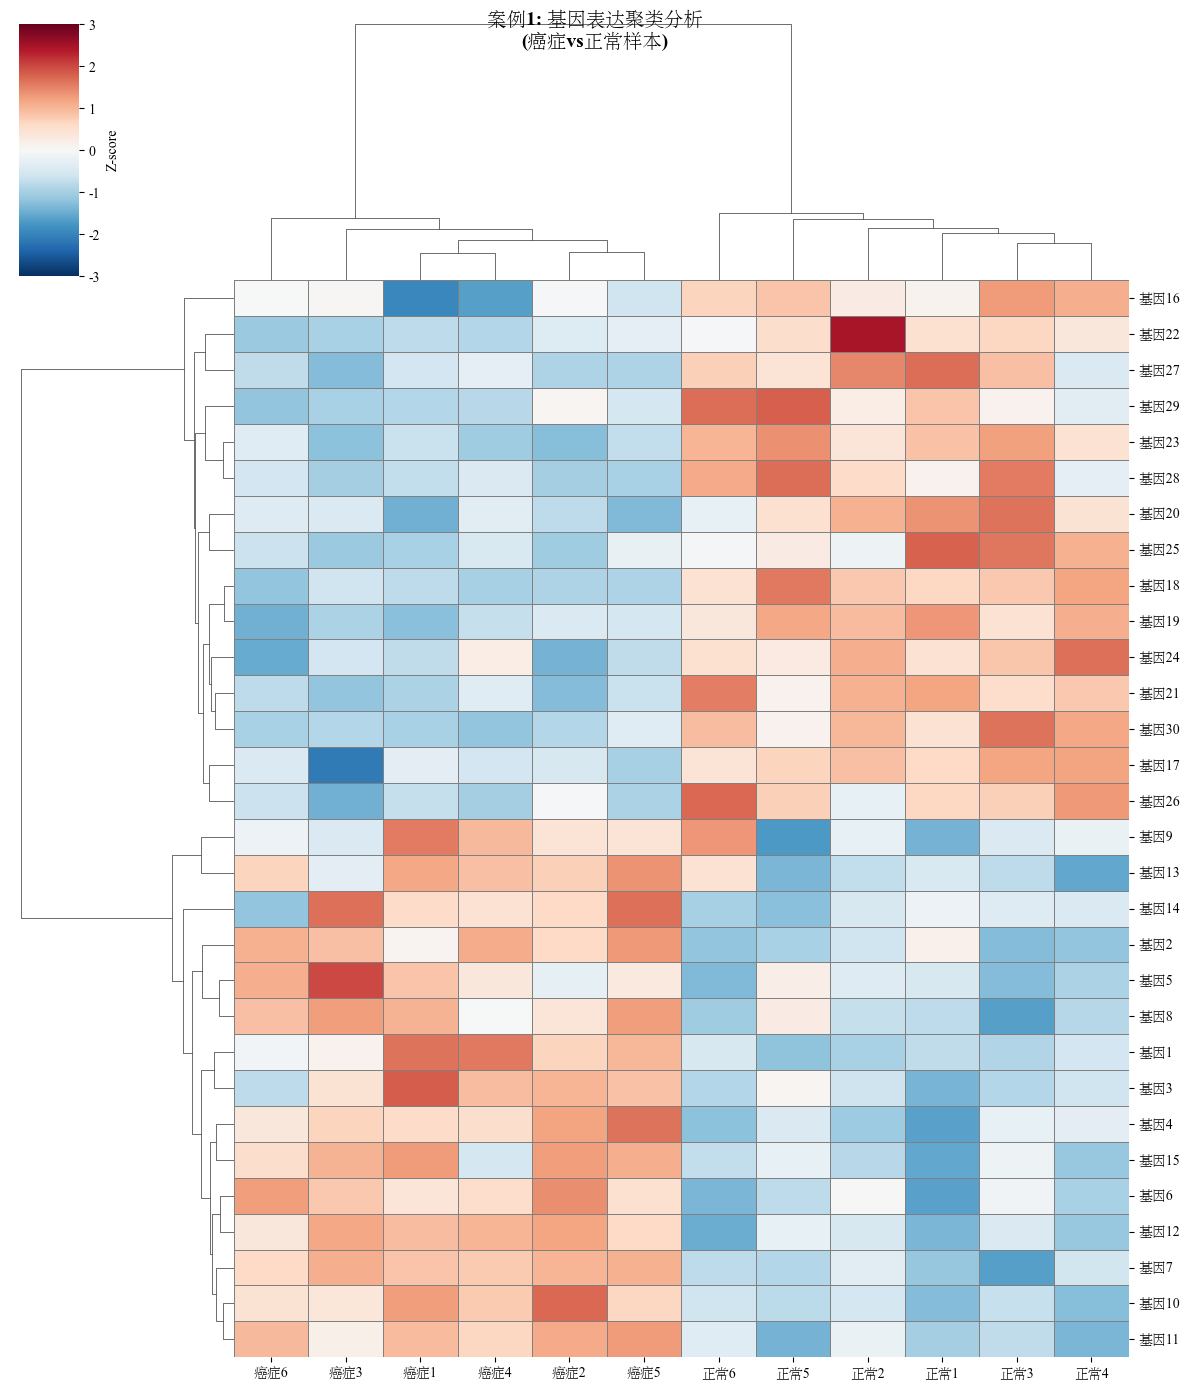


# ========== 案例 2：学生成绩分组分析 ==========


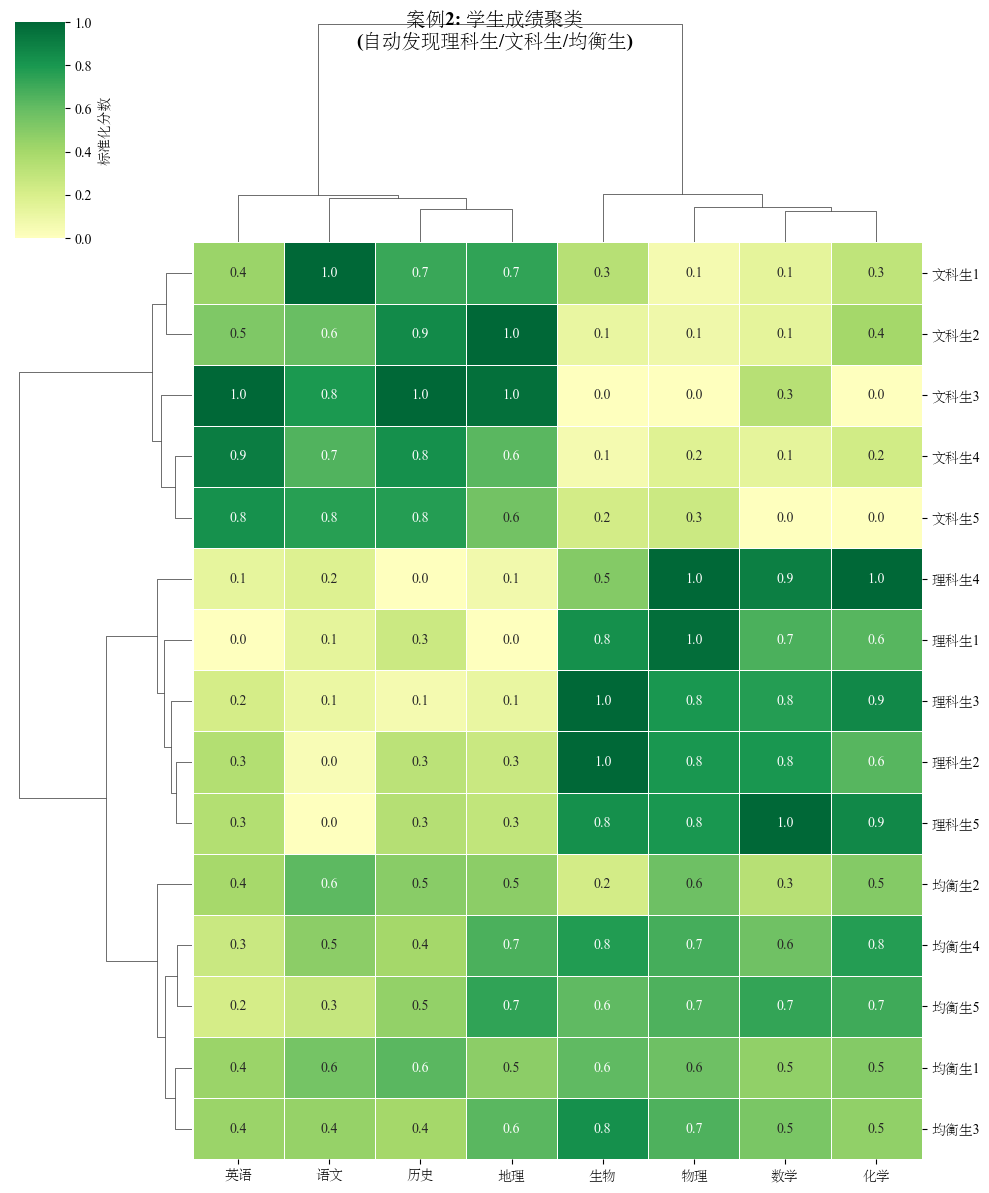


# ========== 案例 3：时间序列模式聚类 ==========


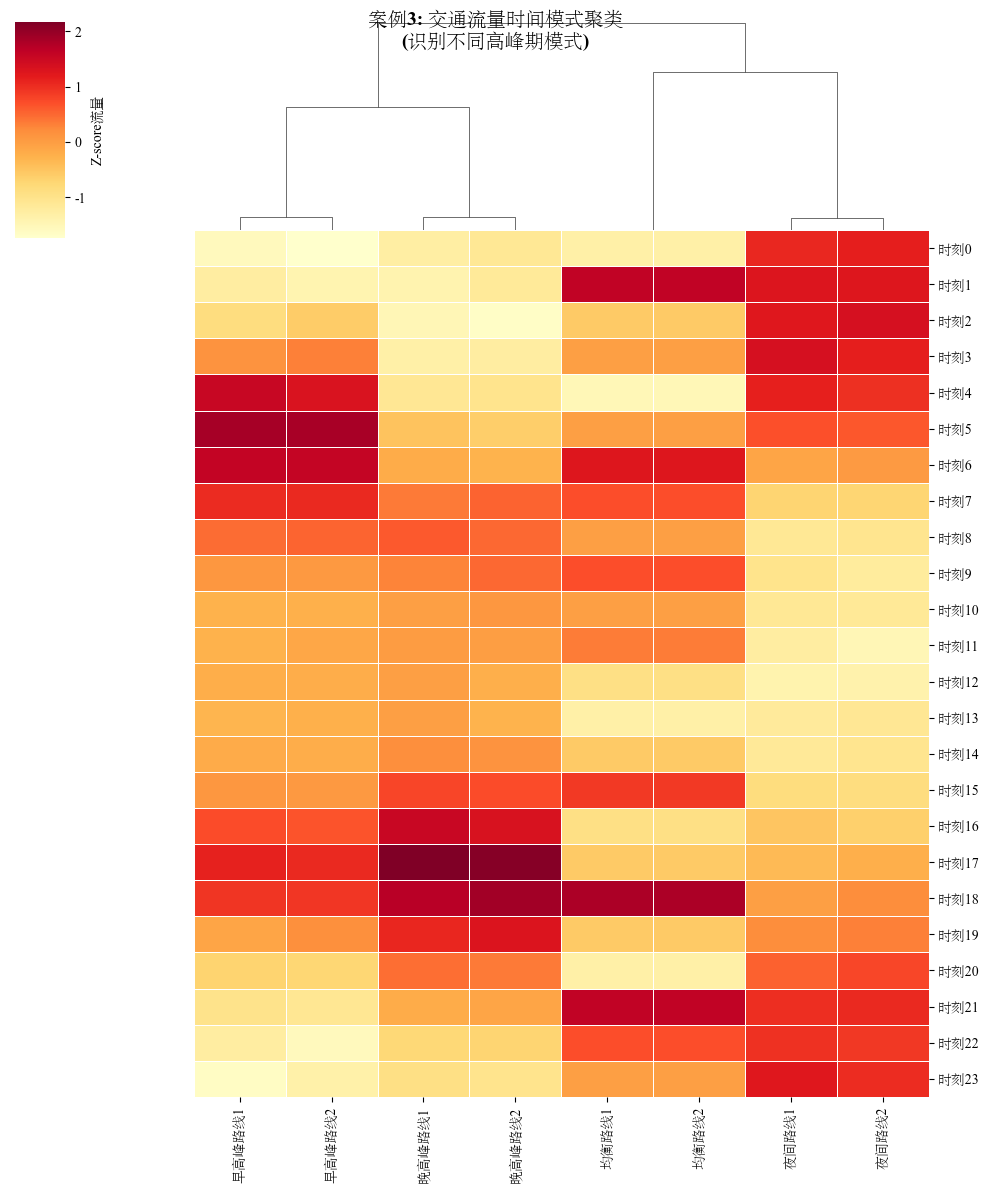

In [13]:
# ==================== 第五部分：实际应用案例 ====================
print("\n" + "=" * 80)  # 打印换行和80个等号，创建分隔线，标记第五部分开始
print("【第五部分】实际应用案例")  # 打印部分标题，说明展示clustermap实际应用案例
print("=" * 80)  # 打印80个等号，结束分隔线

# ========== 案例 1：基因表达分析 ==========
print("\n# ========== 案例 1：基因表达分析 ==========")  # 打印案例标题，说明基因表达分析
# 创建模拟的癌症vs正常样本基因表达数据
cancer_samples = [f'癌症{i+1}' for i in range(6)]  # 定义6个癌症样本名称
normal_samples = [f'正常{i+1}' for i in range(6)]  # 定义6个正常样本名称
all_samples = cancer_samples + normal_samples  # 合并为12个样本名称
gene_names = [f'基因{i+1}' for i in range(30)]  # 定义30个基因名称

# 癌症样本某些基因高表达，某些低表达
cancer_expr = pd.DataFrame(
    np.concatenate([
        np.random.randn(15, 6) + 2,  # 前15个基因高表达，偏移+2
        np.random.randn(15, 6) - 1.5  # 后15个基因低表达，偏移-1.5
    ]),
    columns=cancer_samples,  # 设置列名为癌症样本
    index=gene_names)  # 设置行名为基因名称

# 正常样本相反模式
normal_expr = pd.DataFrame(
    np.concatenate([
        np.random.randn(15, 6) - 0.5,  # 前15个基因低表达，偏移-0.5
        np.random.randn(15, 6) + 1.5  # 后15个基因高表达，偏移+1.5
    ]),
    columns=normal_samples,  # 设置列名为正常样本
    index=gene_names)  # 设置行名为基因名称

gene_data = pd.concat([cancer_expr, normal_expr],
                      axis=1)  # 合并癌症和正常样本数据，生成30x12矩阵

g21 = sns.clustermap(
    gene_data,  # 绘制基因表达clustermap
    z_score=0,  # 对每行（基因）进行Z分数标准化
    figsize=(12, 14),  # 设置画布尺寸为12x14英寸，适应大矩阵
    cmap='RdBu_r',  # 使用红蓝反转调色板，突出正负表达
    center=0,  # 设置颜色中心点为0
    vmin=-3,  # 设置颜色映射最小值为-3，限制值域
    vmax=3,  # 设置颜色映射最大值为3，限制值域
    method='average',  # 使用平均连接法进行聚类
    metric='correlation',  # 使用相关距离（1-相关系数）度量
    linewidths=0.5,  # 设置网格线宽度为0.5，细腻显示
    linecolor='gray',  # 设置网格线颜色为灰色，适中对比
    cbar_kws={'label': 'Z-score'})  # 设置颜色条标签为“Z-score”
g21.fig.suptitle(
    '案例1: 基因表达聚类分析\n(癌症vs正常样本)',  # 设置标题，说明基因表达分析
    fontsize=14,
    fontweight='bold',
    y=0.99)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染基因表达clustermap

# ========== 案例 2：学生成绩聚类 ==========
print("\n# ========== 案例 2：学生成绩分组分析 ==========")  # 打印案例标题，说明学生成绩分组
# 创建三类学生：理科强、文科强、均衡
science_students = pd.DataFrame(
    {
        '语文': np.random.randint(60, 75, 5),  # 文科科目分数较低（60-75）
        '数学': np.random.randint(85, 98, 5),  # 理科科目分数较高（85-98）
        '英语': np.random.randint(70, 80, 5),  # 中间分数（70-80）
        '物理': np.random.randint(85, 98, 5),  # 理科科目分数较高
        '化学': np.random.randint(80, 95, 5),  # 理科科目分数较高
        '生物': np.random.randint(75, 90, 5),  # 理科科目分数较高
        '历史': np.random.randint(60, 75, 5),  # 文科科目分数较低
        '地理': np.random.randint(65, 78, 5)  # 文科科目分数较低
    },
    index=[f'理科生{i+1}' for i in range(5)])  # 设置行名为理科生1-5

arts_students = pd.DataFrame(
    {
        '语文': np.random.randint(85, 98, 5),  # 文科科目分数较高（85-98）
        '数学': np.random.randint(65, 78, 5),  # 理科科目分数较低（65-78）
        '英语': np.random.randint(80, 95, 5),  # 文科科目分数较高
        '物理': np.random.randint(60, 75, 5),  # 理科科目分数较低
        '化学': np.random.randint(60, 75, 5),  # 理科科目分数较低
        '生物': np.random.randint(65, 78, 5),  # 理科科目分数较低
        '历史': np.random.randint(85, 98, 5),  # 文科科目分数较高
        '地理': np.random.randint(80, 95, 5)  # 文科科目分数较高
    },
    index=[f'文科生{i+1}' for i in range(5)])  # 设置行名为文科生1-5

balanced_students = pd.DataFrame(
    {
        '语文': np.random.randint(75, 88, 5),  # 所有科目分数均衡（75-88）
        '数学': np.random.randint(75, 88, 5),
        '英语': np.random.randint(75, 88, 5),
        '物理': np.random.randint(75, 88, 5),
        '化学': np.random.randint(75, 88, 5),
        '生物': np.random.randint(75, 88, 5),
        '历史': np.random.randint(75, 88, 5),
        '地理': np.random.randint(75, 88, 5)
    },
    index=[f'均衡生{i+1}' for i in range(5)])  # 设置行名为均衡生1-5

student_scores = pd.concat(
    [science_students, arts_students, balanced_students])  # 合并三类学生数据，生成15x8矩阵

g22 = sns.clustermap(
    student_scores,  # 绘制学生成绩clustermap
    standard_scale=1,  # 对每列（科目）进行标准化（均值0，标准差1）
    figsize=(10, 12),  # 设置画布尺寸为10x12英寸
    cmap='RdYlGn',  # 使用红黄绿调色板，突出分数高低
    center=0,  # 设置颜色中心点为0
    method='ward',  # 使用Ward方法，基于方差最小化聚类
    metric='euclidean',  # 使用欧氏距离度量
    annot=True,  # 显示单元格数值
    fmt='.1f',  # 数值保留1位小数
    linewidths=0.5,  # 设置网格线宽度为0.5
    cbar_kws={'label': '标准化分数'})  # 设置颜色条标签为“标准化分数”
g22.fig.suptitle(
    '案例2: 学生成绩聚类\n(自动发现理科生/文科生/均衡生)',  # 设置标题，说明学生分组效果
    fontsize=14,
    fontweight='bold',
    y=0.99)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染学生成绩clustermap

# ========== 案例 3：时间序列模式识别 ==========
print("\n# ========== 案例 3：时间序列模式聚类 ==========")  # 打印案例标题，说明时间序列模式聚类
# 创建不同模式的时间序列
hours = list(range(24))  # 定义24小时时间点
# 早高峰模式
morning_pattern = np.array([
    10, 15, 30, 50, 80, 90, 85, 70, 60, 50, 45, 40, 38, 40, 42, 45, 60, 75, 65,
    50, 35, 25, 15, 12
])  # 定义早高峰模式，流量在早晨高
# 晚高峰模式
evening_pattern = np.array([
    15, 12, 10, 12, 15, 25, 35, 50, 55, 50, 45, 40, 38, 40, 45, 55, 75, 90, 85,
    70, 50, 35, 25, 18
])  # 定义晚高峰模式，流量在傍晚高
# 全天均匀模式
uniform_pattern = np.array(
    [45 + np.random.randint(-10, 10) for _ in range(24)])  # 定义全天均匀模式，波动较小
# 夜间模式
night_pattern = np.array([
    80, 85, 90, 85, 80, 70, 50, 30, 20, 15, 12, 10, 10, 12, 15, 20, 30, 40, 50,
    60, 70, 75, 78, 82
])  # 定义夜间模式，流量在深夜高

time_patterns = pd.DataFrame({
    f'时刻{h}': [
        morning_pattern[h] + np.random.randint(-5, 5),  # 早高峰路线1，添加随机噪声
        morning_pattern[h] + np.random.randint(-5, 5),  # 早高峰路线2
        evening_pattern[h] + np.random.randint(-5, 5),  # 晚高峰路线1
        evening_pattern[h] + np.random.randint(-5, 5),  # 晚高峰路线2
        uniform_pattern[h],  # 均衡路线1
        uniform_pattern[h],  # 均衡路线2
        night_pattern[h] + np.random.randint(-5, 5),  # 夜间路线1
        night_pattern[h] + np.random.randint(-5, 5)  # 夜间路线2
    ]
    for h in hours
}).T  # 创建24x8矩阵，行是时间点，列是路线
time_patterns.columns = [
    '早高峰路线1', '早高峰路线2', '晚高峰路线1', '晚高峰路线2', '均衡路线1', '均衡路线2', '夜间路线1', '夜间路线2'
]  # 设置列名为不同路线

g23 = sns.clustermap(
    time_patterns,  # 绘制时间序列clustermap
    z_score=1,  # 对每列（路线）进行Z分数标准化
    figsize=(10, 12),  # 设置画布尺寸为10x12英寸
    cmap='YlOrRd',  # 使用黄橙红调色板，突出流量强度
    method='ward',  # 使用Ward方法，基于方差最小化聚类
    row_cluster=False,  # 禁用行聚类，保持时间点顺序
    col_cluster=True,  # 启用列聚类，聚类不同路线
    linewidths=0.5,  # 设置网格线宽度为0.5
    cbar_kws={'label': 'Z-score流量'})  # 设置颜色条标签为“Z-score流量”
g23.fig.suptitle(
    '案例3: 交通流量时间模式聚类\n(识别不同高峰期模式)',  # 设置标题，说明时间模式聚类效果
    fontsize=14,
    fontweight='bold',
    y=0.99)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染时间序列clustermap


# ========== 案例 4：综合应用 - 完整配置 ==========


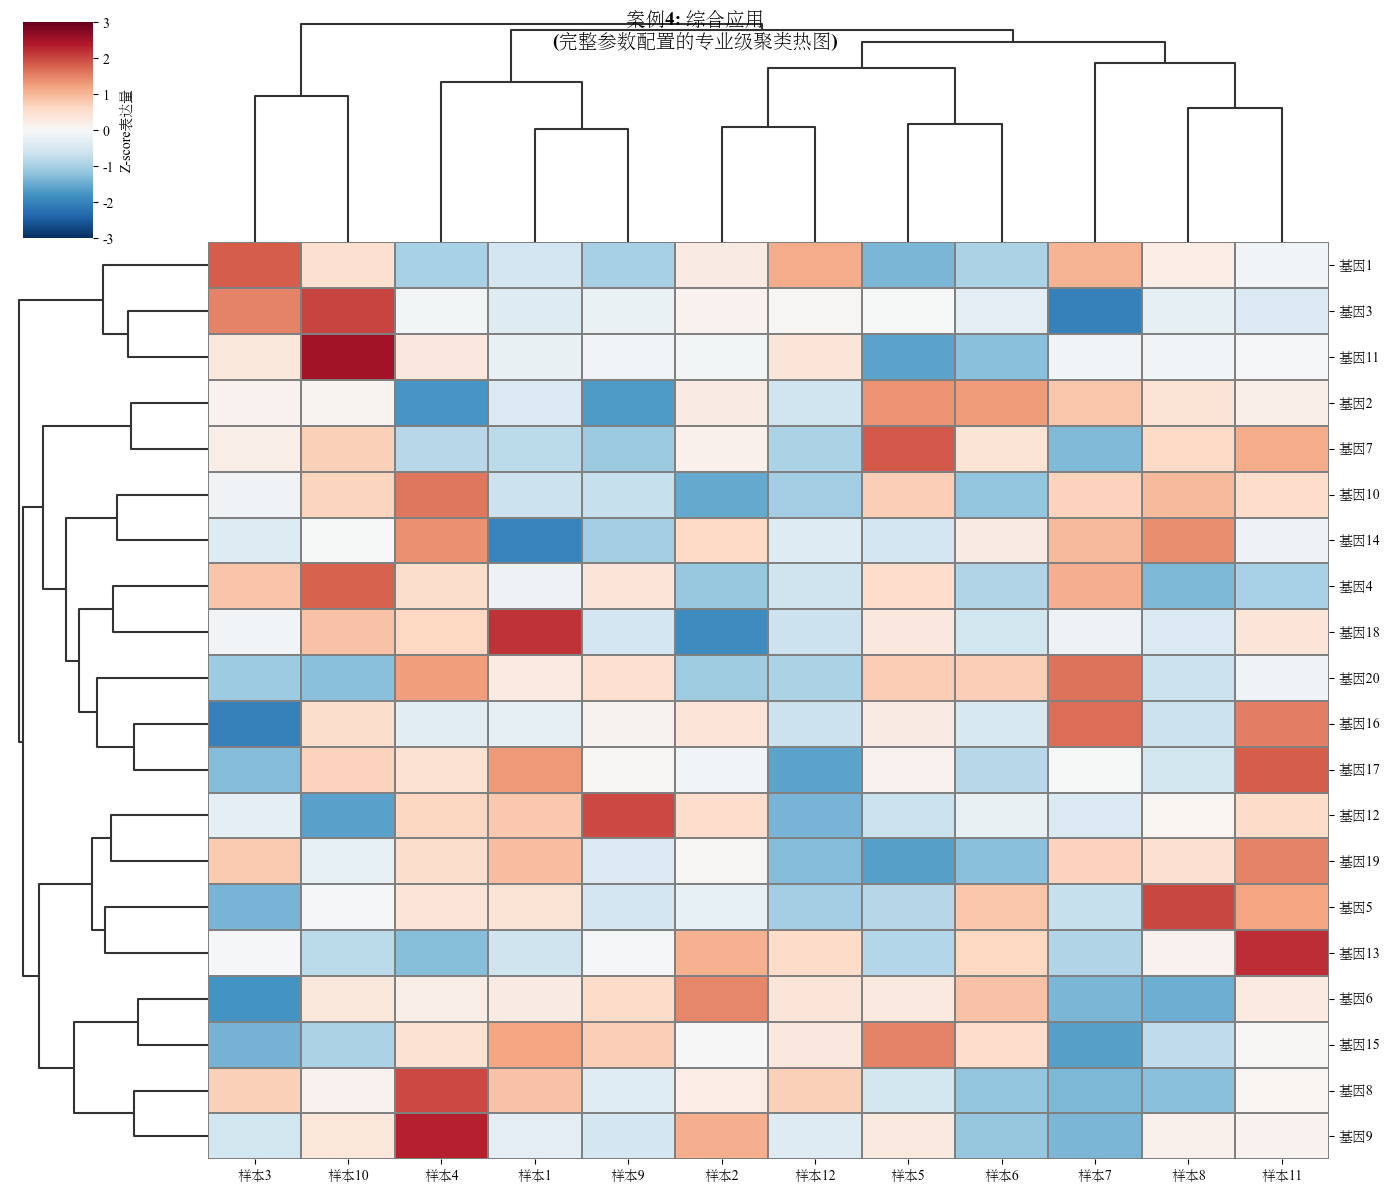

In [14]:
# ========== 案例 4：综合应用 - 多参数组合 ==========
print("\n# ========== 案例 4：综合应用 - 完整配置 ==========")  # 打印案例标题，说明综合应用案例
g24 = sns.clustermap(
    gene_expression,  # 使用gene_expression数据集，20x12基因表达矩阵
    z_score=0,  # 对每行（基因）进行Z分数标准化（均值0，标准差1）
    method='ward',  # 使用Ward方法，基于方差最小化聚类
    metric='euclidean',  # 使用欧氏距离度量点间距离
    cmap='RdBu_r',  # 使用红蓝反转调色板，突出正负表达值
    center=0,  # 设置颜色中心点为0，适合标准化数据
    vmin=-3,  # 设置颜色映射最小值为-3，限制值域
    vmax=3,  # 设置颜色映射最大值为3，限制值域
    figsize=(14, 12),  # 设置画布尺寸为14x12英寸，适应大矩阵
    linewidths=0.3,  # 设置网格线宽度为0.3，细腻显示
    linecolor='gray',  # 设置网格线颜色为灰色，适中对比
    dendrogram_ratio=(.15, .2),  # 设置行树宽度占比0.15，列树高度占比0.2
    cbar_kws={  # 设置颜色条参数
        'label': 'Z-score表达量',  # 设置颜色条标签为“Z-score表达量”
        'shrink': 0.8  # 缩小颜色条至80%长度，优化布局
    },
    tree_kws={'linewidths': 1.5})  # 设置树状图线条宽度为1.5，适中突出
g24.fig.suptitle(
    '案例4: 综合应用\n(完整参数配置的专业级聚类热图)',  # 设置标题，说明综合配置效果
    fontsize=14,
    fontweight='bold',
    y=0.99)  # 标题字体14，粗体，位置略低
plt.show()  # 显示图表，渲染综合配置的clustermap

In [15]:
print("\n" + "=" * 80)
print("📊 Seaborn clustermap 教程完成!")
print("=" * 80)
print("\n✅ 核心功能总结:")
print("\n【基础参数】")
print("  • data - 数据矩阵")
print("  • annot - 显示数值")
print("  • fmt - 数值格式")
print("  • cmap - 调色板")
print("  • figsize - 图形大小")
print("\n【聚类控制】")
print("  • row_cluster - 是否聚类行(True/False)")
print("  • col_cluster - 是否聚类列(True/False)")
print("  • method - 聚类方法:")
print("    - 'average': 平均连接(默认)")
print("    - 'complete': 完全连接")
print("    - 'ward': 沃德方差最小化")
print("    - 'single': 单连接")
print("  • metric - 距离度量:")
print("    - 'euclidean': 欧氏距离(默认)")
print("    - 'correlation': 相关距离")
print("    - 'cityblock': 曼哈顿距离")
print("    - 'cosine': 余弦距离")
print("\n【数据标准化】")
print("  • z_score - Z分数标准化(0=行, 1=列)")
print("  • standard_scale - 标准化(0=行, 1=列)")
print("\n【外观定制】")
print("  • dendrogram_ratio - 树状图比例")
print("  • cbar_pos - 颜色条位置")
print("  • cbar_kws - 颜色条参数")
print("  • tree_kws - 树状图样式")
print("  • linewidths/linecolor - 网格线")
print("  • mask - 遮罩部分数据")
print("\n" + "=" * 80)
print("💡 使用场景:")
print("  1. 基因表达分析 - 发现基因表达模式")
print("  2. 学生成绩分组 - 识别学习特点")
print("  3. 时间序列聚类 - 发现时间模式")
print("  4. 客户分群 - 市场细分")
print("  5. 特征相关性 - 变量关系探索")
print("\n🎯 参数选择建议:")
print("  • 基因/样本聚类 → z_score=0 (行标准化)")
print("  • 特征聚类 → z_score=1 (列标准化)")
print("  • 相似度聚类 → metric='correlation'")
print("  • 距离聚类 → metric='euclidean'")
print("  • 紧凑簇 → method='complete' 或 'ward'")
print("  • 链状簇 → method='single'")
print("=" * 80)
print("\n🔍 clustermap vs heatmap:")
print("  【clustermap】自动聚类 + 树状图")
print("    ✓ 自动层次聚类")
print("    ✓ 显示树状图")
print("    ✓ 发现数据模式")
print("    ✗ 图级函数，不能画在ax上")
print("\n  【heatmap】简单热图")
print("    ✓ 轴级函数，灵活布局")
print("    ✓ 控制精确")
print("    ✗ 不自动聚类")
print("    ✗ 无树状图")
print("=" * 80)


📊 Seaborn clustermap 教程完成!

✅ 核心功能总结:

【基础参数】
  • data - 数据矩阵
  • annot - 显示数值
  • fmt - 数值格式
  • cmap - 调色板
  • figsize - 图形大小

【聚类控制】
  • row_cluster - 是否聚类行(True/False)
  • col_cluster - 是否聚类列(True/False)
  • method - 聚类方法:
    - 'average': 平均连接(默认)
    - 'complete': 完全连接
    - 'ward': 沃德方差最小化
    - 'single': 单连接
  • metric - 距离度量:
    - 'euclidean': 欧氏距离(默认)
    - 'correlation': 相关距离
    - 'cityblock': 曼哈顿距离
    - 'cosine': 余弦距离

【数据标准化】
  • z_score - Z分数标准化(0=行, 1=列)
  • standard_scale - 标准化(0=行, 1=列)

【外观定制】
  • dendrogram_ratio - 树状图比例
  • cbar_pos - 颜色条位置
  • cbar_kws - 颜色条参数
  • tree_kws - 树状图样式
  • linewidths/linecolor - 网格线
  • mask - 遮罩部分数据

💡 使用场景:
  1. 基因表达分析 - 发现基因表达模式
  2. 学生成绩分组 - 识别学习特点
  3. 时间序列聚类 - 发现时间模式
  4. 客户分群 - 市场细分
  5. 特征相关性 - 变量关系探索

🎯 参数选择建议:
  • 基因/样本聚类 → z_score=0 (行标准化)
  • 特征聚类 → z_score=1 (列标准化)
  • 相似度聚类 → metric='correlation'
  • 距离聚类 → metric='euclidean'
  • 紧凑簇 → method='complete' 或 'ward'
  • 链状簇 → method='single'

🔍 clustermap vs heatmap:
  【cl